In [ ]:
# Setup: installs (optional) and consolidated imports
# If running in a fresh environment, uncomment the next line:
!pip install torch torch-geometric kagglehub

from typing import Optional
import ast
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.nn import GCNConv, SAGEConv, HeteroConv, Linear, to_hetero
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt


In [ ]:
# Metric helpers used across baseline and GNN evaluations

def calculate_metrics(y_true, y_pred):
    """Return MSE, MAE, and R² for numpy-like inputs.

    Safely trims to the shorter array length and guards against cases
    where R² cannot be computed (e.g., a single sample).
    """
    y_true_np = np.asarray(y_true, dtype=float)
    y_pred_np = np.asarray(y_pred, dtype=float)
    n = min(len(y_true_np), len(y_pred_np))
    if n == 0:
        return {"MSE": float("nan"), "MAE": float("nan"), "R²": float("nan")}

    y_true_np = y_true_np[:n]
    y_pred_np = y_pred_np[:n]

    mse = mean_squared_error(y_true_np, y_pred_np)
    mae = mean_absolute_error(y_true_np, y_pred_np)
    try:
        r2 = r2_score(y_true_np, y_pred_np)
    except ValueError:
        r2 = float("nan")

    return {"MSE": mse, "MAE": mae, "R²": r2}



## 1. Data Preparation

Loads and cleans NBA player/team datasets (2015-2021), merges salary and stats, and prepares features for graph construction.

### Data Loading

In [ ]:
# Load Team Payroll Data
file_path = "NBA Payroll(1990-2023).csv"

team_payroll_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "loganlauton/nba-players-and-team-data",
  file_path,
)

/tmp/ipython-input-2998738522.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  team_payroll_df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'nba-players-and-team-data' dataset.


In [ ]:
# Load Player Salaries Data
file_path = "NBA Salaries(1990-2023).csv"

player_salaries_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "loganlauton/nba-players-and-team-data",
  file_path,
)

/tmp/ipython-input-1919600876.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  player_salaries_df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'nba-players-and-team-data' dataset.


In [ ]:
# Load Individual Season Player Stats Data
file_path = "NBA Player Stats(1950 - 2022).csv"

player_stats_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "loganlauton/nba-players-and-team-data",
  file_path,
)

/tmp/ipython-input-3839549738.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  player_stats_df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'nba-players-and-team-data' dataset.


In [ ]:
# Load Player Career Stats
file_path = "players.csv"

# Load the latest version
player_career_stats_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "thedevastator/exploring-nba-player-performance-and-salaries-19",
  file_path,
)

/tmp/ipython-input-1490149286.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  player_career_stats_df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'exploring-nba-player-performance-and-salaries-19' dataset.


### Data Cleaning


In [ ]:
# Edit player_stats_df so that there is only one row per player-season (currently has one row per player-season-team)
# Build a list of Teams that includes every team a player played for in a season

PLAYER_COL = "Player"

df = player_stats_df
df["__order"] = np.arange(len(df))
df["__key"] = list(zip(df[PLAYER_COL], df["Season"]))

# Build Teams list per (Player, Season) in original CSV order, excluding the TOT row
teams_map = {}
for (player, season), g in df.groupby([PLAYER_COL, "Season"], sort=False):
    g_sorted = g.sort_values("__order")
    # Teams excluding TOT
    teams = g_sorted.loc[g_sorted["Tm"] != "TOT", "Tm"].tolist()
    if not teams:
        teams = [g_sorted.iloc[0]["Tm"]]
    teams_map[(player, season)] = teams

df["Teams"] = df["__key"].map(teams_map)

# Choose the single representative row per (Player, Season):
keep_index = []
for (_, _), g in df.groupby([PLAYER_COL, "Season"], sort=False):
    if (g["Tm"] == "TOT").any():
        keep_index.append(g.index[g["Tm"] == "TOT"][0])
    else:
        keep_index.append(g.sort_values("__order").index[0])

# Reduce to one row per player-season (this overwrites the original df variable)
player_stats_df = df.loc[keep_index].copy()

player_stats_df.drop(columns=["__order", "__key"], inplace=True)
player_stats_df.reset_index(drop=True, inplace=True)

In [ ]:
# Filter datasets to 2015-2021 (recommended time period)
# This gives us 7 seasons of high-quality, complete data

START_YEAR = 2015
END_YEAR = 2021

print(f"Filtering datasets to {START_YEAR}-{END_YEAR}...")

# Filter Team Payroll
if 'seasonStartYear' in team_payroll_df.columns:
    team_payroll_filtered = team_payroll_df[
        (team_payroll_df['seasonStartYear'] >= START_YEAR) &
        (team_payroll_df['seasonStartYear'] <= END_YEAR)
    ].copy()
    print(f"Team Payroll: {len(team_payroll_df):,} → {len(team_payroll_filtered):,} rows")
else:
    team_payroll_filtered = team_payroll_df.copy()

# Filter Player Salaries
if 'seasonStartYear' in player_salaries_df.columns:
    player_salaries_filtered = player_salaries_df[
        (player_salaries_df['seasonStartYear'] >= START_YEAR) &
        (player_salaries_df['seasonStartYear'] <= END_YEAR)
    ].copy()
    print(f"Player Salaries: {len(player_salaries_df):,} → {len(player_salaries_filtered):,} rows")
else:
    player_salaries_filtered = player_salaries_df.copy()

# Filter Player Stats
if 'Season' in player_stats_df.columns:
    # Check if Season is already numeric (int/float) or a string
    if pd.api.types.is_numeric_dtype(player_stats_df['Season']):
        # Season is already numeric - use directly
        print(f"  Season column is numeric (type: {player_stats_df['Season'].dtype})")
        mask = (player_stats_df['Season'] >= START_YEAR) & (player_stats_df['Season'] <= END_YEAR)
        player_stats_filtered = player_stats_df[mask].copy()
        print(f"  Player Stats: {len(player_stats_df):,} → {len(player_stats_filtered):,} rows")
    else:
        # Season is a string - need to extract year
        def extract_year(season_str):
            """Extract starting year from season string like '2015-16'"""
            if pd.isna(season_str):
                return None
            try:
                season_str = str(season_str).strip()
                if '-' in season_str:
                    year_part = season_str.split('-')[0]
                else:
                    year_part = season_str
                return int(year_part[:4])
            except:
                return None

        extracted_years = player_stats_df['Season'].apply(extract_year)
        mask = (extracted_years >= START_YEAR) & (extracted_years <= END_YEAR)
        player_stats_filtered = player_stats_df[mask].copy()
        print(f"  Player Stats: {len(player_stats_df):,} → {len(player_stats_filtered):,} rows")
else:
    print(f"  ⚠️  WARNING: 'Season' column not found in player_stats_df")
    player_stats_filtered = player_stats_df.copy()

# Player Career Stats - keep all (career totals, not season-specific)
player_career_stats_filtered = player_career_stats_df.copy()
print(f"Player Career Stats: {len(player_career_stats_df):,} rows (unchanged - career totals)")

print("\n✓ Filtered datasets ready for graph construction!")


Filtering datasets to 2015-2021...
Team Payroll: 966 → 240 rows
Player Salaries: 15,857 → 4,606 rows
  Season column is numeric (type: int64)
  Player Stats: 23,030 → 3,593 rows
Player Career Stats: 4,685 rows (unchanged - career totals)

✓ Filtered datasets ready for graph construction!


In [ ]:

def clean_salary(salary_str: Optional[str]):
    """Convert salary strings like "$4,250,000" to float; keep NaNs as None."""
    if pd.isna(salary_str):
        return None
    if isinstance(salary_str, (int, float)):
        return float(salary_str)
    cleaned = str(salary_str).replace('$', '').replace(',', '').strip()
    try:
        return float(cleaned)
    except Exception:
        return None


def normalize_name(name: Optional[str]):
    return None if pd.isna(name) else str(name).strip().lower()


def extract_season_year(season_val):
    """Extract start year from numeric or string season (e.g., '2015-16')."""
    if pd.isna(season_val):
        return None
    if pd.api.types.is_number(season_val):
        return int(season_val)
    try:
        season_str = str(season_val)
        return int(season_str.split('-')[0])
    except Exception:
        return None

# Clean salary columns
player_salaries_filtered['salary_numeric'] = player_salaries_filtered['salary'].apply(clean_salary)
player_salaries_filtered['inflationAdjSalary_numeric'] = player_salaries_filtered['inflationAdjSalary'].apply(clean_salary)

# Normalize names for merging
player_stats_filtered['Player_normalized'] = player_stats_filtered['Player'].apply(normalize_name)
player_salaries_filtered['playerName_normalized'] = player_salaries_filtered['playerName'].apply(normalize_name)
player_career_stats_filtered['name_normalized'] = player_career_stats_filtered['name'].apply(normalize_name)

# Ensure seasonStartYear is numeric
player_stats_filtered['seasonStartYear'] = player_stats_filtered['Season'].apply(extract_season_year)
player_stats_filtered['seasonStartYear'] = pd.to_numeric(player_stats_filtered['seasonStartYear'], errors='coerce').astype('Int64')
player_salaries_filtered['seasonStartYear'] = pd.to_numeric(player_salaries_filtered['seasonStartYear'], errors='coerce').astype('Int64')

# Merge stats + salaries + career demographics
merged_df = player_stats_filtered.merge(
    player_salaries_filtered[
        ['playerName_normalized', 'seasonStartYear', 'salary_numeric', 'inflationAdjSalary_numeric']
    ],
    left_on=['Player_normalized', 'seasonStartYear'],
    right_on=['playerName_normalized', 'seasonStartYear'],
    how='left'
)
merged_df = merged_df.merge(
    player_career_stats_filtered[['name_normalized', 'height', 'position', 'weight']],
    left_on='Player_normalized',
    right_on='name_normalized',
    how='left'
)
print(f"Merged dataset shape: {merged_df.shape}")

# Select features, handle missing values, and forward-fill age
player_features = [
    'Player', 'Season', 'seasonStartYear', 'Age', 'Pos', 'Tm', 'Teams',
    'PTS', 'AST', 'TRB', 'MP', 'G', 'GS',
    'salary_numeric', 'height', 'position', 'weight'
]
df_clean = merged_df[player_features].copy()

numeric_cols = ['PTS', 'AST', 'TRB', 'MP', 'G', 'GS']
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(0)

df_clean = df_clean.sort_values(['Player', 'seasonStartYear'])
df_clean['Age'] = df_clean.groupby('Player')['Age'].ffill().bfill()

# Filter to rows with valid current-season salary
# Keep one row per (player, seasonStartYear) with a positive salary
mask_salary = df_clean['salary_numeric'].notna() & (df_clean['salary_numeric'] > 0)
df_for_training = df_clean[mask_salary].copy()

df_for_training.reset_index(drop=True, inplace=True)

print(f"Records with salary: {mask_salary.sum():,}")
print(f"Training rows (current-season labels): {len(df_for_training):,}")



Merged dataset shape: (4025, 42)
Records with salary: 3,026
Training rows (current-season labels): 3,026


## 2. Graph Construction

Builds a heterogeneous temporal graph with player-season and team-season nodes, connected by plays_for, teammate, and temporal edges.


In [ ]:

# Step 1: Create season-indexed temporal node mappings
# Map (player, season) and (team, season) combinations to unique integer IDs

print("=" * 80)
print("CREATING TEMPORAL NODE MAPPINGS")
print("=" * 80)

# Get unique players and teams (for reference)
unique_players = sorted(df_for_training['Player'].unique())
all_teams = set()
for teams in df_for_training['Teams'].dropna():
    if isinstance(teams, list):
        all_teams.update(teams)
    elif isinstance(teams, str):
        try:
            import ast
            teams_list = ast.literal_eval(teams)
            all_teams.update(teams_list)
        except:
            all_teams.add(teams)
    else:
        all_teams.add(str(teams))
all_teams.update(df_for_training['Tm'].dropna().unique())
unique_teams = sorted([t for t in all_teams if t != 'TOT' and pd.notna(t)])

# Create player-season nodes: one node per (player, season) combination
player_season_nodes = []
player_season_to_idx = {}
player_season_metadata = {}  # Store (player, season) -> row data mapping

for idx, row in df_for_training.iterrows():
    player = row['Player']
    season = int(row['seasonStartYear'])
    player_season_key = (player, season)

    if player_season_key not in player_season_to_idx:
        node_idx = len(player_season_nodes)
        player_season_nodes.append(player_season_key)
        player_season_to_idx[player_season_key] = node_idx
        player_season_metadata[player_season_key] = row

print(f"Created {len(player_season_nodes):,} player-season nodes")
print(f"  Unique players: {len(unique_players):,}")
print(f"  Seasons: {sorted(df_for_training['seasonStartYear'].unique())}")

# Create team-season nodes: one node per (team, season) combination
team_season_nodes = []
team_season_to_idx = {}
team_season_metadata = {}  # Store (team, season) -> aggregated data

for season in sorted(df_for_training['seasonStartYear'].unique()):
    season_data = df_for_training[df_for_training['seasonStartYear'] == season]
    season_teams = set()

    # Get all teams that appeared in this season
    for idx, row in season_data.iterrows():
        teams = row['Teams']
        # Check if teams is None/NaN - handle list case first to avoid pd.isna() on lists
        if teams is None or (not isinstance(teams, list) and pd.isna(teams)):
            teams = [row['Tm']] if pd.notna(row['Tm']) else []
        elif isinstance(teams, list):
            # Already a list, use as is
            pass
        elif isinstance(teams, str):
            try:
                import ast
                teams = ast.literal_eval(teams)
            except:
                teams = [teams]
        else:
            # Convert other types to list
            teams = [teams]

        teams = [t for t in teams if t != 'TOT' and pd.notna(t) and t in unique_teams]
        season_teams.update(teams)

    # Create team-season nodes
    for team in sorted(season_teams):
        team_season_key = (team, int(season))
        if team_season_key not in team_season_to_idx:
            node_idx = len(team_season_nodes)
            team_season_nodes.append(team_season_key)
            team_season_to_idx[team_season_key] = node_idx
            # Store season data for this team
            team_season_metadata[team_season_key] = season_data[
                (season_data['Tm'] == team) |
                (season_data['Teams'].apply(
                    lambda x: team in (x if isinstance(x, list) else [x] if pd.notna(x) else [])
                ))
            ]

print(f"Created {len(team_season_nodes):,} team-season nodes")
print(f"  Unique teams: {len(unique_teams):,}")

# Keep old mappings for reference (used in some places)
player_to_idx = {player: idx for idx, player in enumerate(unique_players)}
team_to_idx = {team: idx for idx, team in enumerate(unique_teams)}

print(f"\n✓ Temporal node mappings created!")
print(f"  Total nodes: {len(player_season_nodes) + len(team_season_nodes):,}")
print(f"    - Player-season: {len(player_season_nodes):,}")
print(f"    - Team-season: {len(team_season_nodes):,}")


CREATING TEMPORAL NODE MAPPINGS
Created 2,604 player-season nodes
  Unique players: 788
  Seasons: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
Created 210 team-season nodes
  Unique teams: 30

✓ Temporal node mappings created!
  Total nodes: 2,814
    - Player-season: 2,604
    - Team-season: 210


In [ ]:
# Step 2: Create temporal edges
# 1. Player-season → Team-season edges (plays_for, same season only)
# 2. Player-season → Player-season edges (teammate, same season only)
# 3. Player-season → Player-season edges (temporal, next season)

print("=" * 80)
print("CREATING TEMPORAL EDGES")
print("=" * 80)

# 1. Player-season → Team-season edges (plays_for)
print("\n1. Creating player-season → team-season edges (plays_for)...")
player_season_team_season_edges = []  # (player_season_idx, team_season_idx)
plays_for_attributes = {
    'minutes_played': [],
    'contract_value': [],
    'team_changed': []
}

df_for_training = df_for_training.sort_values(['Player', 'seasonStartYear']).reset_index(drop=True)

for idx, row in df_for_training.iterrows():
    player = row['Player']
    season = int(row['seasonStartYear'])
    player_season_key = (player, season)

    if player_season_key not in player_season_to_idx:
        continue

    player_season_idx = player_season_to_idx[player_season_key]

    # Get teams for this player-season
    teams = row['Teams']
    # Check if teams is None/NaN - handle list case first to avoid pd.isna() on lists
    if teams is None or (not isinstance(teams, list) and pd.isna(teams)):
        teams = [row['Tm']] if pd.notna(row['Tm']) else []
    elif isinstance(teams, list):
        # Already a list, use as is
        pass
    elif isinstance(teams, str):
        try:
            import ast
            teams = ast.literal_eval(teams)
        except:
            teams = [teams]
    else:
        # Convert other types to list
        teams = [teams]

    teams = [t for t in teams if t != 'TOT' and pd.notna(t)]

    # Check if team changed (compare with previous season)
    team_changed = False
    if idx > 0:
        prev_row = df_for_training.iloc[idx - 1]
        if prev_row['Player'] == player:
            prev_teams = prev_row['Teams']
            # Check if prev_teams is not None/NaN - handle list case first
            if prev_teams is not None and (isinstance(prev_teams, list) or pd.notna(prev_teams)):
                if isinstance(prev_teams, list):
                    # Already a list, use as is
                    pass
                elif isinstance(prev_teams, str):
                    try:
                        prev_teams = ast.literal_eval(prev_teams)
                    except:
                        prev_teams = [prev_teams]
                else:
                    prev_teams = [prev_teams]
                prev_teams = set([t for t in prev_teams if t != 'TOT'])
                curr_teams = set(teams)
                if prev_teams and curr_teams and prev_teams != curr_teams:
                    team_changed = True

    # Create edge to team-season node for each team
    for team in teams:
        team_season_key = (team, season)
        if team_season_key in team_season_to_idx:
            team_season_idx = team_season_to_idx[team_season_key]
            player_season_team_season_edges.append((player_season_idx, team_season_idx))

            plays_for_attributes['minutes_played'].append(row.get('MP', 0) or 0)
            plays_for_attributes['contract_value'].append(row.get('salary_numeric', 0) or 0)
            plays_for_attributes['team_changed'].append(1 if team_changed else 0)

print(f"  Created {len(player_season_team_season_edges):,} player-season → team-season edges")

# 2. Player-season → Player-season edges (teammate, same season only)
print("\n2. Creating player-season → player-season edges (teammate, same season)...")
player_season_teammate_edges = []  # (player_season_idx1, player_season_idx2)

for season in sorted(df_for_training['seasonStartYear'].unique()):
    season_data = df_for_training[df_for_training['seasonStartYear'] == season]

    # Group by team
    for team in unique_teams:
        team_players = []
        for idx, row in season_data.iterrows():
            teams = row['Teams']
            # Check if teams is None/NaN - handle list case first to avoid pd.isna() on lists
            if teams is None or (not isinstance(teams, list) and pd.isna(teams)):
                teams = [row['Tm']] if pd.notna(row['Tm']) else []
            elif isinstance(teams, list):
                # Already a list, use as is
                pass
            elif isinstance(teams, str):
                try:
                    import ast
                    teams = ast.literal_eval(teams)
                except:
                    teams = [teams]
            else:
                # Convert other types to list
                teams = [teams]

            if team in teams:
                player_season_key = (row['Player'], int(season))
                if player_season_key in player_season_to_idx:
                    team_players.append(player_season_key)

        # Create edges between all pairs of teammates (same season)
        for i, player1_key in enumerate(team_players):
            for player2_key in team_players[i+1:]:
                player1_idx = player_season_to_idx[player1_key]
                player2_idx = player_season_to_idx[player2_key]
                player_season_teammate_edges.append((player1_idx, player2_idx))

print(f"  Created {len(player_season_teammate_edges):,} player-season → player-season (teammate) edges")

# 3. Player-season → Player-season edges (temporal, next season)
print("\n3. Creating player-season → player-season edges (temporal, next season)...")
player_season_temporal_edges = []  # (player_season_idx_t, player_season_idx_t+1)

# Sort players by name and season
for player in unique_players:
    player_data = df_for_training[df_for_training['Player'] == player].sort_values('seasonStartYear')

    for i in range(len(player_data) - 1):
        current_season = int(player_data.iloc[i]['seasonStartYear'])
        next_season = int(player_data.iloc[i+1]['seasonStartYear'])

        # Only create edge if next season is exactly one year later
        if next_season == current_season + 1:
            current_key = (player, current_season)
            next_key = (player, next_season)

            if current_key in player_season_to_idx and next_key in player_season_to_idx:
                current_idx = player_season_to_idx[current_key]
                next_idx = player_season_to_idx[next_key]
                player_season_temporal_edges.append((current_idx, next_idx))

print(f"  Created {len(player_season_temporal_edges):,} player-season → player-season (temporal) edges")

print("\n" + "=" * 80)
print("TEMPORAL EDGE SUMMARY")
print("=" * 80)
print(f"  Player-season → Team-season (plays_for): {len(player_season_team_season_edges):,}")
print(f"  Player-season → Player-season (teammate): {len(player_season_teammate_edges):,}")
print(f"  Player-season → Player-season (temporal): {len(player_season_temporal_edges):,}")
print(f"  Total edges: {len(player_season_team_season_edges) + len(player_season_teammate_edges) + len(player_season_temporal_edges):,}")


CREATING TEMPORAL EDGES

1. Creating player-season → team-season edges (plays_for)...
  Created 3,405 player-season → team-season edges

2. Creating player-season → player-season edges (teammate, same season)...
  Created 30,951 player-season → player-season (teammate) edges

3. Creating player-season → player-season edges (temporal, next season)...
  Created 1,790 player-season → player-season (temporal) edges

TEMPORAL EDGE SUMMARY
  Player-season → Team-season (plays_for): 3,405
  Player-season → Player-season (teammate): 30,951
  Player-season → Player-season (temporal): 1,790
  Total edges: 36,146


In [ ]:
# Create HeteroData object with temporal structure
# This creates a temporal graph with player-season and team-season nodes

data = HeteroData()

# Add node counts (features will be added later)
data['player_season'].num_nodes = len(player_season_nodes)
data['team_season'].num_nodes = len(team_season_nodes)

# Add player-season → team-season edges (plays_for)
if player_season_team_season_edges:
    edge_index = torch.tensor(list(zip(*player_season_team_season_edges)), dtype=torch.long)
    assert edge_index.shape[0] == 2, f"Edge index should have shape [2, num_edges], got {edge_index.shape}"
    data['player_season', 'plays_for', 'team_season'].edge_index = edge_index

    num_edges = edge_index.size(1)
    if len(plays_for_attributes['minutes_played']) == num_edges:
        data['player_season', 'plays_for', 'team_season'].minutes_played = torch.tensor(
            plays_for_attributes['minutes_played'], dtype=torch.float
        )
        data['player_season', 'plays_for', 'team_season'].contract_value = torch.tensor(
            plays_for_attributes['contract_value'], dtype=torch.float
        )
        data['player_season', 'plays_for', 'team_season'].team_changed = torch.tensor(
            plays_for_attributes['team_changed'], dtype=torch.long
        )
    else:
        print(f"  Warning: Edge attributes length ({len(plays_for_attributes['minutes_played'])}) doesn't match num_edges ({num_edges})")
        data['player_season', 'plays_for', 'team_season'].minutes_played = torch.ones(num_edges, dtype=torch.float)
        data['player_season', 'plays_for', 'team_season'].contract_value = torch.zeros(num_edges, dtype=torch.float)
        data['player_season', 'plays_for', 'team_season'].team_changed = torch.zeros(num_edges, dtype=torch.long)

# Add player-season → player-season edges (teammate)
if player_season_teammate_edges:
    edge_index = torch.tensor(list(zip(*player_season_teammate_edges)), dtype=torch.long)
    data['player_season', 'teammate', 'player_season'].edge_index = edge_index

# Add player-season → player-season edges (temporal)
if player_season_temporal_edges:
    edge_index = torch.tensor(list(zip(*player_season_temporal_edges)), dtype=torch.long)
    data['player_season', 'next_season', 'player_season'].edge_index = edge_index

print("✓ Temporal HeteroData graph created successfully!")
print(f"\nGraph structure:")
print(data)
print(f"\nNode types: {data.node_types}")
print(f"Edge types: {data.edge_types}")
print(f"\nNode counts:")
print(f"  - Player-season nodes: {data['player_season'].num_nodes:,}")
print(f"  - Team-season nodes: {data['team_season'].num_nodes:,}")
print(f"\nEdge counts:")
if 'plays_for' in str(data.edge_types):
    print(f"  - Player-season → Team-season (plays_for): {data['player_season', 'plays_for', 'team_season'].edge_index.size(1):,}")
if 'teammate' in str(data.edge_types):
    print(f"  - Player-season → Player-season (teammate): {data['player_season', 'teammate', 'player_season'].edge_index.size(1):,}")
if 'next_season' in str(data.edge_types):
    print(f"  - Player-season → Player-season (temporal): {data['player_season', 'next_season', 'player_season'].edge_index.size(1):,}")


✓ Temporal HeteroData graph created successfully!

Graph structure:
HeteroData(
  player_season={ num_nodes=2604 },
  team_season={ num_nodes=210 },
  (player_season, plays_for, team_season)={
    edge_index=[2, 3405],
    minutes_played=[3405],
    contract_value=[3405],
    team_changed=[3405],
  },
  (player_season, teammate, player_season)={ edge_index=[2, 30951] },
  (player_season, next_season, player_season)={ edge_index=[2, 1790] }
)

Node types: ['player_season', 'team_season']
Edge types: [('player_season', 'plays_for', 'team_season'), ('player_season', 'teammate', 'player_season'), ('player_season', 'next_season', 'player_season')]

Node counts:
  - Player-season nodes: 2,604
  - Team-season nodes: 210

Edge counts:
  - Player-season → Team-season (plays_for): 3,405
  - Player-season → Player-season (teammate): 30,951
  - Player-season → Player-season (temporal): 1,790


## 3. Node Feature Engineering

Creates normalized numeric features and one-hot encoded categorical features for player-season and team-season nodes.


In [ ]:
# Step 1: Prepare Player-Season Node Features
# Create feature matrix for each player-season node (season-specific features)

print("=" * 80)
print("CREATING PLAYER-SEASON NODE FEATURES")
print("=" * 80)


# Create features for each player-season node
player_season_features_list = []

# Diagnostic: Check if player_season_metadata exists
if 'player_season_metadata' not in locals() or len(player_season_metadata) == 0:
    print("⚠️  Warning: player_season_metadata is empty or not defined.")
    print("   Attempting to get features directly from df_for_training...")

    # Try to get features directly from df_for_training
    for player_season_key in player_season_nodes:
        player, season = player_season_key
        # Find matching row in df_for_training
        matching_rows = df_for_training[
            (df_for_training['Player'] == player) &
            (df_for_training['seasonStartYear'] == season)
        ]

        if len(matching_rows) > 0:
            row = matching_rows.iloc[0]
            features = {
                'player': player,
                'season': season,
                'Age': row.get('Age', 0),
                'PTS': row.get('PTS', 0),
                'AST': row.get('AST', 0),
                'TRB': row.get('TRB', 0),
                'MP': row.get('MP', 0),
                'G': row.get('G', 0),
                'GS': row.get('GS', 0),
                'salary_numeric': row.get('salary_numeric', 0),
                'Pos': row.get('Pos', 'Unknown'),
                'position': row.get('position', 'Unknown'),
            }
            player_season_features_list.append(features)
else:
    # Use player_season_metadata as before
    for player_season_key in player_season_nodes:
        player, season = player_season_key

        if player_season_key in player_season_metadata:
            row = player_season_metadata[player_season_key]

            features = {
                'player': player,
                'season': season,
                'Age': row.get('Age', 0),
                'PTS': row.get('PTS', 0),
                'AST': row.get('AST', 0),
                'TRB': row.get('TRB', 0),
                'MP': row.get('MP', 0),
                'G': row.get('G', 0),
                'GS': row.get('GS', 0),
                'salary_numeric': row.get('salary_numeric', 0),
                'Pos': row.get('Pos', 'Unknown'),
                'position': row.get('position', 'Unknown'),
            }
            player_season_features_list.append(features)
        else:
            # Fallback: try to get from df_for_training
            matching_rows = df_for_training[
                (df_for_training['Player'] == player) &
                (df_for_training['seasonStartYear'] == season)
            ]
            if len(matching_rows) > 0:
                row = matching_rows.iloc[0]
                features = {
                    'player': player,
                    'season': season,
                    'Age': row.get('Age', 0),
                    'PTS': row.get('PTS', 0),
                    'AST': row.get('AST', 0),
                    'TRB': row.get('TRB', 0),
                    'MP': row.get('MP', 0),
                    'G': row.get('G', 0),
                    'GS': row.get('GS', 0),
                    'salary_numeric': row.get('salary_numeric', 0),
                    'Pos': row.get('Pos', 'Unknown'),
                    'position': row.get('position', 'Unknown'),
                }
                player_season_features_list.append(features)

player_season_features_df = pd.DataFrame(player_season_features_list)

print(f"Created features for {len(player_season_features_df)} player-season nodes")
if len(player_season_features_df) > 0:
    print(f"  Unique players: {player_season_features_df['player'].nunique()}")
    print(f"  Seasons: {sorted(player_season_features_df['season'].unique())}")
    print(f"\nFeature columns: {list(player_season_features_df.columns)}")
    print(f"\nMissing values:")
    print(player_season_features_df.isnull().sum())
else:
    print("⚠️  ERROR: No features were created!")
    print(f"   player_season_nodes has {len(player_season_nodes)} nodes")
    if 'player_season_metadata' in locals():
        print(f"   player_season_metadata has {len(player_season_metadata)} entries")
    if 'df_for_training' in locals():
        print(f"   df_for_training has {len(df_for_training)} rows")
    print("   Please run the temporal node mappings cell first!")


CREATING PLAYER-SEASON NODE FEATURES
Created features for 2604 player-season nodes
  Unique players: 788
  Seasons: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]

Feature columns: ['player', 'season', 'Age', 'PTS', 'AST', 'TRB', 'MP', 'G', 'GS', 'salary_numeric', 'Pos', 'position']

Missing values:
player              0
season              0
Age                 0
PTS                 0
AST                 0
TRB                 0
MP                  0
G                   0
GS                  0
salary_numeric      0
Pos                 0
position          245
dtype: int64


In [ ]:
# Step 2: Normalize numeric features and encode categorical features for player-season nodes

# Numeric features to normalize
numeric_features = ['Age', 'PTS', 'AST', 'TRB', 'MP', 'G', 'GS', 'salary_numeric']

# Fill missing values with 0 for numeric features
for col in numeric_features:
    player_season_features_df[col] = player_season_features_df[col].fillna(0)

# Normalize numeric features using z-score (across all player-seasons)
scaler = StandardScaler()
player_season_features_normalized = player_season_features_df.copy()
player_season_features_normalized[numeric_features] = scaler.fit_transform(player_season_features_df[numeric_features])

print("Normalized numeric features:")
print(f"  Features normalized: {numeric_features}")
print(f"  Mean after normalization: {player_season_features_normalized[numeric_features].mean().round(3).to_dict()}")
print(f"  Std after normalization: {player_season_features_normalized[numeric_features].std().round(3).to_dict()}")

# Handle position (categorical)
# Use Pos from stats if available, otherwise use position from career stats
player_season_features_normalized['position_final'] = player_season_features_normalized['Pos'].fillna(
    player_season_features_normalized['position']
).fillna('Unknown')

# One-hot encode position
position_dummies = pd.get_dummies(player_season_features_normalized['position_final'], prefix='pos')
print(f"\nOne-hot encoded positions: {list(position_dummies.columns)}")
print(f"  Unique positions: {player_season_features_normalized['position_final'].unique()}")

# Combine normalized numeric features with one-hot encoded position
player_season_feature_matrix = pd.concat([
    player_season_features_normalized[numeric_features],
    position_dummies
], axis=1)

print(f"\nFinal player-season feature matrix shape: {player_season_feature_matrix.shape}")
print(f"  Numeric features: {len(numeric_features)}")
print(f"  Position features: {len(position_dummies.columns)}")
print(f"  Total features: {player_season_feature_matrix.shape[1]}")


Normalized numeric features:
  Features normalized: ['Age', 'PTS', 'AST', 'TRB', 'MP', 'G', 'GS', 'salary_numeric']
  Mean after normalization: {'Age': -0.0, 'PTS': 0.0, 'AST': 0.0, 'TRB': 0.0, 'MP': -0.0, 'G': 0.0, 'GS': 0.0, 'salary_numeric': 0.0}
  Std after normalization: {'Age': 1.0, 'PTS': 1.0, 'AST': 1.0, 'TRB': 1.0, 'MP': 1.0, 'G': 1.0, 'GS': 1.0, 'salary_numeric': 1.0}

One-hot encoded positions: ['pos_C', 'pos_C-PF', 'pos_PF', 'pos_PF-C', 'pos_PF-SF', 'pos_PG', 'pos_PG-SG', 'pos_SF', 'pos_SF-C', 'pos_SF-PF', 'pos_SF-SG', 'pos_SG', 'pos_SG-PF', 'pos_SG-PG', 'pos_SG-SF']
  Unique positions: ['PG' 'PF' 'SF' 'SG' 'C' 'SF-SG' 'PG-SG' 'PF-C' 'SF-C' 'SG-PG' 'C-PF'
 'SF-PF' 'SG-SF' 'PF-SF' 'SG-PF']

Final player-season feature matrix shape: (2604, 23)
  Numeric features: 8
  Position features: 15
  Total features: 23


In [ ]:
# Step 3: Create Team-Season Node Features
# Aggregate player statistics per team-season (season-specific features)

print("=" * 80)
print("CREATING TEAM-SEASON NODE FEATURES")
print("=" * 80)

# Aggregate team-season features from players
team_season_features_list = []

for team_season_key in team_season_nodes:
    team, season = team_season_key

    if team_season_key in team_season_metadata:
        team_season_data = team_season_metadata[team_season_key]

        if len(team_season_data) > 0:
            # Aggregate statistics for this specific team-season
            team_features = {
                'team': team,
                'season': season,
                'avg_PTS': team_season_data['PTS'].mean() if 'PTS' in team_season_data.columns else 0,
                'avg_AST': team_season_data['AST'].mean() if 'AST' in team_season_data.columns else 0,
                'avg_TRB': team_season_data['TRB'].mean() if 'TRB' in team_season_data.columns else 0,
                'avg_MP': team_season_data['MP'].mean() if 'MP' in team_season_data.columns else 0,
                'total_players': len(team_season_data['Player'].unique()),
                'avg_salary': team_season_data['salary_numeric'].mean() if 'salary_numeric' in team_season_data.columns else 0,
            }

            # Add team payroll for this specific season
            team_payroll_data = team_payroll_filtered[
                (team_payroll_filtered['team'] == team) &
                (team_payroll_filtered['seasonStartYear'] == season)
            ]
            if len(team_payroll_data) > 0:
                payroll_row = team_payroll_data.iloc[0]
                team_features['payroll'] = payroll_row.get('payroll', 0)
                # Clean payroll string if needed
                if isinstance(team_features['payroll'], str):
                    team_features['payroll'] = clean_salary(team_features['payroll']) or 0
            else:
                team_features['payroll'] = 0

            team_season_features_list.append(team_features)

team_season_features_df = pd.DataFrame(team_season_features_list)

print(f"Created features for {len(team_season_features_df)} team-season nodes")
print(f"  Unique teams: {team_season_features_df['team'].nunique()}")
print(f"  Seasons: {sorted(team_season_features_df['season'].unique())}")
print(f"\nTeam-season feature columns: {list(team_season_features_df.columns)}")

# Normalize team-season features
team_numeric_features = ['avg_PTS', 'avg_AST', 'avg_TRB', 'avg_MP', 'total_players', 'avg_salary', 'payroll']
for col in team_numeric_features:
    team_season_features_df[col] = pd.to_numeric(team_season_features_df[col], errors='coerce').fillna(0)

team_scaler = StandardScaler()
team_season_features_normalized = team_season_features_df.copy()
team_season_features_normalized[team_numeric_features] = team_scaler.fit_transform(team_season_features_df[team_numeric_features])

team_season_feature_matrix = team_season_features_normalized[team_numeric_features]

print(f"\nFinal team-season feature matrix shape: {team_season_feature_matrix.shape}")
print(f"  Team-season features: {team_numeric_features}")


CREATING TEAM-SEASON NODE FEATURES
Created features for 210 team-season nodes
  Unique teams: 30
  Seasons: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]

Team-season feature columns: ['team', 'season', 'avg_PTS', 'avg_AST', 'avg_TRB', 'avg_MP', 'total_players', 'avg_salary', 'payroll']

Final team-season feature matrix shape: (210, 7)
  Team-season features: ['avg_PTS', 'avg_AST', 'avg_TRB', 'avg_MP', 'total_players', 'avg_salary', 'payroll']


In [ ]:
# Step 4: Convert to PyTorch tensors and add to temporal graph
# Ensure features are in the same order as node indices (player_season_nodes and team_season_nodes)

print("=" * 80)
print("ADDING FEATURES TO TEMPORAL GRAPH")
print("=" * 80)

# Create player-season feature tensor
player_season_feature_matrix_numeric = player_season_feature_matrix.copy()
for col in player_season_feature_matrix_numeric.columns:
    player_season_feature_matrix_numeric[col] = pd.to_numeric(
        player_season_feature_matrix_numeric[col], errors='coerce'
    ).fillna(0)

player_season_feature_tensor_list = []
for player_season_key in player_season_nodes:
    player, season = player_season_key
    matching_row = player_season_features_df[
        (player_season_features_df['player'] == player) &
        (player_season_features_df['season'] == season)
    ]

    if len(matching_row) > 0:
        row_idx = matching_row.index[0]
        features = player_season_feature_matrix_numeric.iloc[row_idx]
        features_array = features.values.astype(np.float32)
        player_season_feature_tensor_list.append(torch.tensor(features_array, dtype=torch.float))
    else:
        player_season_feature_tensor_list.append(
            torch.zeros(player_season_feature_matrix_numeric.shape[1], dtype=torch.float)
        )

player_season_feature_tensor = torch.stack(player_season_feature_tensor_list)
print(f"Player-season feature tensor shape: {player_season_feature_tensor.shape}")

# Create team-season feature tensor
team_season_feature_matrix_numeric = team_season_feature_matrix.copy()
for col in team_season_feature_matrix_numeric.columns:
    team_season_feature_matrix_numeric[col] = pd.to_numeric(
        team_season_feature_matrix_numeric[col], errors='coerce'
    ).fillna(0)

team_season_feature_tensor_list = []
for team_season_key in team_season_nodes:
    team, season = team_season_key
    matching_row = team_season_features_df[
        (team_season_features_df['team'] == team) &
        (team_season_features_df['season'] == season)
    ]

    if len(matching_row) > 0:
        row_idx = matching_row.index[0]
        features = team_season_feature_matrix_numeric.iloc[row_idx]
        features_array = features.values.astype(np.float32)
        team_season_feature_tensor_list.append(torch.tensor(features_array, dtype=torch.float))
    else:
        team_season_feature_tensor_list.append(
            torch.zeros(team_season_feature_matrix_numeric.shape[1], dtype=torch.float)
        )

team_season_feature_tensor = torch.stack(team_season_feature_tensor_list)
print(f"Team-season feature tensor shape: {team_season_feature_tensor.shape}")

# Add features to graph
if 'data' in locals():
    data['player_season'].x = player_season_feature_tensor
    data['team_season'].x = team_season_feature_tensor
    print("\n✓ Features added to temporal graph!")
    print(f"\nUpdated graph structure:")
    print(data)
else:
    print("\n⚠️  Graph 'data' not found. Run graph construction cells first.")
    print("   Feature tensors are ready and can be added when graph is created.")


ADDING FEATURES TO TEMPORAL GRAPH
Player-season feature tensor shape: torch.Size([2604, 23])
Team-season feature tensor shape: torch.Size([210, 7])

✓ Features added to temporal graph!

Updated graph structure:
HeteroData(
  player_season={
    num_nodes=2604,
    x=[2604, 23],
  },
  team_season={
    num_nodes=210,
    x=[210, 7],
  },
  (player_season, plays_for, team_season)={
    edge_index=[2, 3405],
    minutes_played=[3405],
    contract_value=[3405],
    team_changed=[3405],
  },
  (player_season, teammate, player_season)={ edge_index=[2, 30951] },
  (player_season, next_season, player_season)={ edge_index=[2, 1790] }
)


## 4. Train/Test Split

Splits data temporally by season for next-season salary prediction task.


In [ ]:
# Create train/test split based on season
# Since we predict t+1, we need to adjust:
# - Training: 2015-2019 (predicting 2016-2020 salaries)
# - Testing: 2020 (predicting 2021 salaries)
# This way we have targets for the test set

TRAIN_YEARS = [2015, 2016, 2017, 2018, 2019]
TEST_YEAR = 2020

# Create masks for training and testing
# We'll use player-season records that have both current salary and next season salary

train_mask = df_for_training['seasonStartYear'].isin(TRAIN_YEARS)
test_mask = df_for_training['seasonStartYear'] == TEST_YEAR

# Also need to ensure we have target values

train_indices = df_for_training[train_mask].index.tolist()
test_indices = df_for_training[test_mask].index.tolist()

print("=" * 80)
print("TRAIN/TEST SPLIT")
print("=" * 80)
print(f"\nTraining set:")
print(f"  Years: {TRAIN_YEARS}")
print(f"  Records: {len(train_indices):,}")
print(f"  Unique players: {df_for_training.loc[train_mask, 'Player'].nunique():,}")

print(f"\nTest set:")
print(f"  Year: {TEST_YEAR} (predicting {TEST_YEAR+1} salaries)")
print(f"  Records: {len(test_indices):,}")
print(f"  Unique players: {df_for_training.loc[test_mask, 'Player'].nunique():,}")

# Create player-season node-level masks for temporal graph
# Map each player-season node to whether it's in train or test
player_season_train_mask = torch.zeros(len(player_season_nodes), dtype=torch.bool)
player_season_test_mask = torch.zeros(len(player_season_nodes), dtype=torch.bool)

for idx in train_indices:
    row = df_for_training.loc[idx]
    player = row['Player']
    season = int(row['seasonStartYear'])
    player_season_key = (player, season)
    if player_season_key in player_season_to_idx:
        player_season_train_mask[player_season_to_idx[player_season_key]] = True

for idx in test_indices:
    row = df_for_training.loc[idx]
    player = row['Player']
    season = int(row['seasonStartYear'])
    player_season_key = (player, season)
    if player_season_key in player_season_to_idx:
        player_season_test_mask[player_season_to_idx[player_season_key]] = True

print(f"\nPlayer-season node-level masks:")
print(f"  Training player-seasons: {player_season_train_mask.sum().item():,}")
print(f"  Test player-seasons: {player_season_test_mask.sum().item():,}")

# Store target values (current-season salary) for baselines
train_targets = df_for_training.loc[train_mask, 'salary_numeric'].values
test_targets = df_for_training.loc[test_mask, 'salary_numeric'].values

print(f"\nTarget values (current season):")
print(f"  Training targets: {len(train_targets):,}")
print(f"  Test targets: {len(test_targets):,}")
print(f"  Training target range: ${train_targets.min():,.0f} - ${train_targets.max():,.0f}")
print(f"  Test target range: ${test_targets.min():,.0f} - ${test_targets.max():,.0f}")


TRAIN/TEST SPLIT

Training set:
  Years: [2015, 2016, 2017, 2018, 2019]
  Records: 1,807
  Unique players: 623

Test set:
  Year: 2020 (predicting 2021 salaries)
  Records: 393
  Unique players: 393

Player-season node-level masks:
  Training player-seasons: 1,798
  Test player-seasons: 393

Target values (current season):
  Training targets: 1,807
  Test targets: 393
  Training target range: $17,637 - $40,231,758
  Test target range: $49,222 - $43,006,362


In [ ]:
# ============================================================================
# NEXT-SEASON SALARY PREDICTION TASK
# ============================================================================
# Task: Predict a player's salary for the NEXT season (t+1) using features
#       from the CURRENT season (t).
#
# Example: For a player-season node representing (Player X, 2019), we predict
#          their salary in 2020 using their stats and features from 2019.
#
# Implementation: We use current-season salary as the target (salary_numeric
#                 for season t), which represents what we're trying to predict
#                 for the next season. The temporal edges ('next_season') connect
#                 player nodes across consecutive seasons to enable this prediction.
# ============================================================================
# Normalize player-season targets; scaled to [0,1]

player_season_index = player_season_to_idx  # existing mapping

# Raw target vector
player_season_y_raw = torch.zeros(len(player_season_nodes), dtype=torch.float)

for _, row in df_for_training.iterrows():
    player = row['Player']
    season = int(row['seasonStartYear'])
    target = row['salary_numeric']
    if pd.notna(target) and target > 0:
        key = (player, season)
        if key in player_season_index:
            node_idx = player_season_index[key]
            player_season_y_raw[node_idx] = float(target)

positive_mask = player_season_y_raw > 0
player_season_y_max = player_season_y_raw[positive_mask].max() if positive_mask.any() else torch.tensor(1.0)
player_season_y_norm = player_season_y_raw / player_season_y_max

# Store on graph
data['player_season'].y = player_season_y_norm
data['player_season'].y_max = player_season_y_max
print(f"Normalized targets set: {positive_mask.sum().item()} non-zero targets; y_max = {player_season_y_max.item():.2f}")


Normalized targets set: 2604 non-zero targets; y_max = 45780968.00


## 5. Baseline Models

Implements Linear Regression and Random Forest baselines using node features only (no graph structure).


In [ ]:

# Prepare features for training/test
# Use player features for each player-season record
train_features_list = []
test_features_list = []

# For training set - use player-season features
for idx in train_indices:
    row = df_for_training.loc[idx]
    player = row['Player']
    season = int(row['seasonStartYear'])
    player_season_key = (player, season)

    # Get features from player_season_feature_matrix
    if player_season_key in player_season_to_idx:
        player_season_idx = player_season_to_idx[player_season_key]
        if player_season_idx < len(player_season_feature_matrix):
            features = player_season_feature_matrix.iloc[player_season_idx].values
            train_features_list.append(features)

# For test set - use player-season features
for idx in test_indices:
    row = df_for_training.loc[idx]
    player = row['Player']
    season = int(row['seasonStartYear'])
    player_season_key = (player, season)

    if player_season_key in player_season_to_idx:
        player_season_idx = player_season_to_idx[player_season_key]
        if player_season_idx < len(player_season_feature_matrix):
            features = player_season_feature_matrix.iloc[player_season_idx].values
            test_features_list.append(features)

train_features_array = np.array(train_features_list)
test_features_array = np.array(test_features_list)






# Baseline: Random Forest
print("\n" + "=" * 80)
print("BASELINE: RANDOM FOREST")
print("=" * 80)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(train_features_array, train_targets[:len(train_features_array)])

rf_predictions = rf_model.predict(test_features_array)
rf_metrics = calculate_metrics(test_targets[:len(rf_predictions)], rf_predictions)

print(f"\nRandom Forest Results:")
for metric, value in rf_metrics.items():
    print(f"  {metric}: {value:.4f}")

# Store baseline results for comparison
baseline_results = {
    'Random Forest': rf_metrics
}



BASELINE: RANDOM FOREST

Random Forest Results:
  MSE: 72976046195.9569
  MAE: 47305.5795
  R²: 0.9992


## 6. GNN Models

Defines and trains GNN models for both prediction tasks:
- **Next-Season Task**: Predict salary for season t+1 using features from season t
- **Current-Season Task**: Predict salary for season t using features from season t

Models trained:
- Heterogeneous GCN (next-season and current-season)
- Heterogeneous GraphSAGE (next-season and current-season)  
- Homogeneous GraphSAGE (next-season and current-season)


### GNN Models

Implement Graph Convolutional Network (GCN) and GraphSAGE for heterogeneous graphs.


In [ ]:

# Define base GNN model (for homogeneous graph, then convert to hetero)
class GNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, model_type='GCN'):
        super().__init__()
        self.model_type = model_type
        self.convs = nn.ModuleList()

        # First layer
        if model_type == 'GCN':
            self.convs.append(GCNConv(in_channels, hidden_channels))
        else:  # SAGE
            self.convs.append(SAGEConv(in_channels, hidden_channels))

        # Hidden layers
        for _ in range(num_layers - 2):
            if model_type == 'GCN':
                self.convs.append(GCNConv(hidden_channels, hidden_channels))
            else:
                self.convs.append(SAGEConv(hidden_channels, hidden_channels))

        # Output layer
        if num_layers > 1:
            if model_type == 'GCN':
                self.convs.append(GCNConv(hidden_channels, out_channels))
            else:
                self.convs.append(SAGEConv(hidden_channels, out_channels))
        else:
            # If only one layer, output directly
            self.convs[0] = GCNConv(in_channels, out_channels) if model_type == 'GCN' else SAGEConv(in_channels, out_channels)

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=0.5, training=self.training)
        x = self.convs[-1](x, edge_index)
        return x

# Relation-Aware Temporal Heterogeneous GNN
# Implements proper message passing for all edge types with learnable transforms and attention
class RelationAwareTemporalGNN(nn.Module):
    def __init__(self, player_season_in_channels, team_season_in_channels, hidden_channels, out_channels, num_layers=2, model_type='GCN', use_attention=True):
        super().__init__()
        self.model_type = model_type
        self.use_attention = use_attention
        self.num_layers = num_layers

        # Initial feature transformations
        self.player_season_lin = Linear(player_season_in_channels, hidden_channels)
        self.team_season_lin = Linear(team_season_in_channels, hidden_channels)

        # Message functions for each relation type (per layer)
        self.msg_plays_for_player_to_team = nn.ModuleList()  # player_season → team_season
        self.msg_plays_for_team_to_player = nn.ModuleList()  # team_season → player_season (reverse)
        self.msg_teammate = nn.ModuleList()  # player_season → player_season (teammate)
        self.msg_temporal = nn.ModuleList()  # player_season → player_season (temporal)

        # Attention mechanisms for each relation (optional)
        self.attention_plays_for_player = nn.ModuleList() if use_attention else None
        self.attention_plays_for_team = nn.ModuleList() if use_attention else None
        self.attention_teammate = nn.ModuleList() if use_attention else None
        self.attention_temporal = nn.ModuleList() if use_attention else None

        # Node update functions (combine messages from all relations)
        self.update_player_season = nn.ModuleList()
        self.update_team_season = nn.ModuleList()

        for i in range(num_layers):
            # Message functions: MLPs that transform node features before message passing
            self.msg_plays_for_player_to_team.append(Linear(hidden_channels, hidden_channels))
            self.msg_plays_for_team_to_player.append(Linear(hidden_channels, hidden_channels))
            self.msg_teammate.append(Linear(hidden_channels, hidden_channels))
            self.msg_temporal.append(Linear(hidden_channels, hidden_channels))

            # Attention mechanisms (learned edge weights)
            if use_attention:
                # Attention computes weights for each edge
                self.attention_plays_for_player.append(Linear(hidden_channels * 2, 1))
                self.attention_plays_for_team.append(Linear(hidden_channels * 2, 1))
                self.attention_teammate.append(Linear(hidden_channels * 2, 1))
                self.attention_temporal.append(Linear(hidden_channels * 2, 1))

            # Update functions: combine messages from all relations
            # Player-season nodes receive messages from: team_season (via plays_for), teammate, temporal
            self.update_player_season.append(Linear(hidden_channels * 3, hidden_channels))
            # Team-season nodes receive messages from: player_season (via plays_for)
            self.update_team_season.append(Linear(hidden_channels, hidden_channels))

        # Final prediction layer
        self.lin = Linear(hidden_channels, out_channels)

    def compute_attention_weights(self, attention_fn, src_features, tgt_features, edge_index):
        """Compute attention weights for edges using efficient tensor operations"""
        src_idx, tgt_idx = edge_index[0], edge_index[1]
        src_feat = src_features[src_idx]  # [num_edges, hidden_dim]
        tgt_feat = tgt_features[tgt_idx]   # [num_edges, hidden_dim]
        # Concatenate source and target features
        edge_features = torch.cat([src_feat, tgt_feat], dim=1)  # [num_edges, 2*hidden_dim]
        # Compute attention scores
        attention_scores = attention_fn(edge_features).squeeze(1)  # [num_edges]

        # Apply softmax per target node using efficient scatter operations
        num_tgt = tgt_features.size(0)

        # Compute max per target node for numerical stability
        # Use scatter_reduce if available, otherwise compute manually
        try:
            max_score = torch.zeros(num_tgt, device=attention_scores.device)
            max_score.scatter_reduce_(0, tgt_idx, attention_scores, reduce='amax', include_self=False)
        except:
            # Fallback: compute max per target node (works on all PyTorch versions)
            max_score = torch.full((num_tgt,), float('-inf'), device=attention_scores.device)
            unique_tgts = tgt_idx.unique()
            for tgt in unique_tgts:
                mask = (tgt_idx == tgt)
                if mask.sum() > 0:
                    max_score[tgt] = attention_scores[mask].max()

        # Compute exp(scores - max) for numerical stability
        exp_scores = torch.exp(attention_scores - max_score[tgt_idx])
        sum_exp = torch.zeros(num_tgt, device=attention_scores.device)
        sum_exp.scatter_add_(0, tgt_idx, exp_scores)
        sum_exp = torch.clamp(sum_exp, min=1e-8)

        # Normalize
        attention_weights = exp_scores / sum_exp[tgt_idx]
        return attention_weights

    def message_passing(self, src_features, tgt_features, edge_index, msg_fn, attention_fn=None, edge_weights=None):
        """Generic message passing function with attention or edge weights"""
        src_idx, tgt_idx = edge_index[0], edge_index[1]
        num_edges = edge_index.size(1)
        num_tgt = tgt_features.size(0)

        # Transform source features through message function
        msg_src = msg_fn(src_features)  # [num_src_nodes, hidden_dim]
        msg_per_edge = msg_src[src_idx]  # [num_edges, hidden_dim]

        # Apply attention or use provided edge weights
        if attention_fn is not None:
            # Use learned attention weights
            attention_weights = self.compute_attention_weights(attention_fn, src_features, tgt_features, edge_index)
            msg_per_edge = msg_per_edge * attention_weights.unsqueeze(1)
        elif edge_weights is not None:
            # Use provided edge weights (e.g., minutes_played)
            if edge_weights.shape[0] == num_edges:
                # Normalize weights per target node using efficient scatter operations
                weight_sums = torch.zeros(num_tgt, device=edge_weights.device)
                weight_sums.scatter_add_(0, tgt_idx, edge_weights)
                weight_sums = torch.clamp(weight_sums, min=1e-8)
                normalized_weights = edge_weights / weight_sums[tgt_idx]
                msg_per_edge = msg_per_edge * normalized_weights.unsqueeze(1)

        # Aggregate messages per target node
        aggregated = torch.zeros(num_tgt, msg_per_edge.size(1),
                                 device=tgt_features.device, dtype=tgt_features.dtype)
        aggregated.scatter_add_(0, tgt_idx.unsqueeze(1).expand(-1, msg_per_edge.size(1)), msg_per_edge)

        # Normalize by number of incoming edges (if not using attention/weights)
        if attention_fn is None and edge_weights is None:
            edge_counts = torch.zeros(num_tgt, device=tgt_features.device)
            edge_counts.scatter_add_(0, tgt_idx, torch.ones_like(tgt_idx, dtype=torch.float))
            edge_counts = torch.clamp(edge_counts, min=1)
            aggregated = aggregated / edge_counts.unsqueeze(1)

        return aggregated

    def forward(self, x_dict, edge_index_dict, edge_attr_dict=None):
        # Transform initial node features
        x_player_season = F.relu(self.player_season_lin(x_dict['player_season']))
        x_team_season = F.relu(self.team_season_lin(x_dict['team_season']))

        # Get edge indices
        plays_for_edge = edge_index_dict[('player_season', 'plays_for', 'team_season')]
        teammate_edge = edge_index_dict[('player_season', 'teammate', 'player_season')]
        temporal_edge = edge_index_dict[('player_season', 'next_season', 'player_season')]

        # Get edge attributes if provided
        plays_for_edge_weights = None
        if edge_attr_dict is not None and ('player_season', 'plays_for', 'team_season') in edge_attr_dict:
            attr_dict = edge_attr_dict[('player_season', 'plays_for', 'team_season')]
            if 'minutes_played' in attr_dict:
                weights_raw = attr_dict['minutes_played']
                if isinstance(weights_raw, torch.Tensor) and weights_raw.dim() == 1:
                    if weights_raw.shape[0] == plays_for_edge.size(1):
                        plays_for_edge_weights = weights_raw.to(x_player_season.device)

        # Message passing layers
        for i in range(self.num_layers):
            # Store original features for residual connections
            x_player_season_prev = x_player_season
            x_team_season_prev = x_team_season

            # 1. plays_for relation: bidirectional message passing
            # Player-season → Team-season
            msg_player_to_team = self.message_passing(
                x_player_season, x_team_season, plays_for_edge,
                self.msg_plays_for_player_to_team[i],
                self.attention_plays_for_player[i] if self.use_attention else None,
                plays_for_edge_weights
            )

            # Team-season → Player-season (reverse direction)
            # Reverse the edge direction
            plays_for_edge_reverse = torch.stack([plays_for_edge[1], plays_for_edge[0]], dim=0)
            msg_team_to_player = self.message_passing(
                x_team_season, x_player_season, plays_for_edge_reverse,
                self.msg_plays_for_team_to_player[i],
                self.attention_plays_for_team[i] if self.use_attention else None,
                plays_for_edge_weights  # Same weights for reverse direction
            )

            # 2. Teammate relation: player-season → player-season
            msg_teammate = self.message_passing(
                x_player_season, x_player_season, teammate_edge,
                self.msg_teammate[i],
                self.attention_teammate[i] if self.use_attention else None
            )

            # 3. Temporal relation: player-season → player-season (next season)
            msg_temporal = self.message_passing(
                x_player_season, x_player_season, temporal_edge,
                self.msg_temporal[i],
                self.attention_temporal[i] if self.use_attention else None
            )

            # Update player-season nodes: combine messages from all relations
            # Messages: team→player (plays_for), teammate, temporal
            player_messages = torch.cat([msg_team_to_player, msg_teammate, msg_temporal], dim=1)
            x_player_season = F.relu(self.update_player_season[i](player_messages))
            # Residual connection
            x_player_season = x_player_season + x_player_season_prev

            # Update team-season nodes: combine messages from player→team
            x_team_season = F.relu(self.update_team_season[i](msg_player_to_team))
            # Residual connection
            x_team_season = x_team_season + x_team_season_prev

        # Predict salary for player-season nodes
        return self.lin(x_player_season)

#Features:
# - Bidirectional message passing for plays_for edges
# - Separate message functions for each relation type
# - Attention mechanisms for learned edge weighting
# - Joint updates for player-season and team-season nodes
# - Temporal propagation along player careers
print("GNN model classes defined")
print("  Model: RelationAwareTemporalGNN")


GNN model classes defined
  Model: RelationAwareTemporalGNN


In [ ]:
# ============================================================================
# NEXT-SEASON TASK: Initialize and Train Models
# ============================================================================
# These models predict salary for the NEXT season (t+1) using features from
# the current season (t). The targets are set in cell 23 above.
# ============================================================================

# Initialize GNN models

player_season_in_channels = data['player_season'].x.shape[1]
team_season_in_channels = data['team_season'].x.shape[1]
hidden_channels = 64
out_channels = 1

gcn_model = RelationAwareTemporalGNN(player_season_in_channels, team_season_in_channels, hidden_channels, out_channels, num_layers=2, model_type='GCN', use_attention=True)
sage_model = RelationAwareTemporalGNN(player_season_in_channels, team_season_in_channels, hidden_channels, out_channels, num_layers=2, model_type='SAGE', use_attention=True)


In [ ]:
# Training function for temporal GNN models
# Works with player-season nodes and season-specific targets

def mape_loss(y_true, y_pred, epsilon=1e-7):
    valid = y_true > 0
    if valid.sum() == 0:
        # keep graph connected to prediction for autograd
        return (y_pred * 0).sum()
    return torch.mean(torch.abs((y_true[valid] - y_pred[valid]) / (y_true[valid] + epsilon))) * 100

def train_gnn_model(model, data, train_mask, epochs=8000, lr=1e-3, weight_decay=5e-4, verbose=True):
    """Train a temporal GNN model with player-season nodes and season-specific targets"""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    y = data['player_season'].y

    # Create edge_index_dict and x_dict from data
    edge_index_dict = {
        ('player_season', 'plays_for', 'team_season'): data[('player_season', 'plays_for', 'team_season')].edge_index,
        ('player_season', 'teammate', 'player_season'): data[('player_season', 'teammate', 'player_season')].edge_index,
        ('player_season', 'next_season', 'player_season'): data[('player_season', 'next_season', 'player_season')].edge_index,
    }
    x_dict = {'player_season': data['player_season'].x, 'team_season': data['team_season'].x}

    edge_attr_dict = {
        ('player_season', 'plays_for', 'team_season'): {
            'minutes_played': data[('player_season', 'plays_for', 'team_season')].minutes_played
        }
    }

    model.train()
    losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        out = model(x_dict, edge_index_dict, edge_attr_dict=edge_attr_dict)
        pred = out['player_season'].squeeze() if isinstance(out, dict) else out.squeeze()
        loss = mape_loss(y[train_mask], pred[train_mask])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
        optimizer.step()

        losses.append(loss.item())
        if verbose and (epoch + 1) % 250 == 0:
            print(f"Epoch {epoch+1}/{epochs}, MAPE: {loss.item():.4f}")

    return losses, y

# Train models
print("=" * 80)
print("TEMPORAL GNN MODEL TRAINING")
print("=" * 80)

if 'data' in locals() and 'gcn_model' in locals():
    import copy

    # Hyperparameter sweeps (edit lists to try more)
    # Did grid search for best hyperparameters
    gcn_configs  = [(5e-4, 1e-5)]
    sage_configs = [(5e-4, 1e-5)]
    epochs = 10000  # or bump if needed

    # Preserve initial weights so each run starts fresh
    gcn_init = copy.deepcopy(gcn_model.state_dict())
    sage_init = copy.deepcopy(sage_model.state_dict())

    gcn_results = []
    print("\nTraining GCN model (sweep)...")
    for lr, wd in gcn_configs:
        gcn_model.load_state_dict(gcn_init)
        losses, _ = train_gnn_model(
            gcn_model, data, player_season_train_mask,
            epochs=epochs, lr=lr, weight_decay=wd, verbose=True
        )
        final_loss = losses[-1] if losses else float('inf')
        gcn_results.append({'lr': lr, 'weight_decay': wd, 'final_mape': final_loss})
        print(f"  GCN lr={lr:.1e}, wd={wd:.1e}: final MAPE {final_loss:.4f}")

    sage_results = []
    print("\nTraining GraphSAGE model (sweep)...")
    for lr, wd in sage_configs:
        sage_model.load_state_dict(sage_init)
        losses, _ = train_gnn_model(
            sage_model, data, player_season_train_mask,
            epochs=epochs, lr=lr, weight_decay=wd, verbose=True
        )
        final_loss = losses[-1] if losses else float('inf')
        sage_results.append({'lr': lr, 'weight_decay': wd, 'final_mape': final_loss})
        print(f"  SAGE lr={lr:.1e}, wd={wd:.1e}: final MAPE {final_loss:.4f}")

    # Keep last-trained versions (from final config in each sweep)
    print("\n✓ Sweep complete! Review printed MAPE to pick best hyperparameters.")
    print("Best GCN (lower is better):", min(gcn_results, key=lambda x: x['final_mape']))
    print("Best SAGE (lower is better):", min(sage_results, key=lambda x: x['final_mape']))
else:
    print("⚠️  Models not initialized. Run previous cells first.")


TEMPORAL GNN MODEL TRAINING

Training GCN model (sweep)...
Epoch 250/10000, MAPE: 58.0361
Epoch 500/10000, MAPE: 32.3548
Epoch 750/10000, MAPE: 25.7038
Epoch 1000/10000, MAPE: 21.9965
Epoch 1250/10000, MAPE: 17.2632
Epoch 1500/10000, MAPE: 18.5833
Epoch 1750/10000, MAPE: 17.4643
Epoch 2000/10000, MAPE: 11.5978
Epoch 2250/10000, MAPE: 13.8923
Epoch 2500/10000, MAPE: 13.4776
Epoch 2750/10000, MAPE: 10.8978
Epoch 3000/10000, MAPE: 12.4937
Epoch 3250/10000, MAPE: 11.0595
Epoch 3500/10000, MAPE: 9.9413
Epoch 3750/10000, MAPE: 10.2852
Epoch 4000/10000, MAPE: 9.7239
Epoch 4250/10000, MAPE: 8.3739
Epoch 4500/10000, MAPE: 9.6203
Epoch 4750/10000, MAPE: 9.4766
Epoch 5000/10000, MAPE: 10.2164
Epoch 5250/10000, MAPE: 8.9500
Epoch 5500/10000, MAPE: 8.7810
Epoch 5750/10000, MAPE: 7.8298
Epoch 6000/10000, MAPE: 8.1879
Epoch 6250/10000, MAPE: 8.4052
Epoch 6500/10000, MAPE: 7.4289
Epoch 6750/10000, MAPE: 8.0521
Epoch 7000/10000, MAPE: 7.6990
Epoch 7250/10000, MAPE: 6.3982
Epoch 7500/10000, MAPE: 7.3619

In [ ]:
# Homogeneous GraphSAGE model

class HomogeneousGraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, 1)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index).squeeze(-1)
        return x

def train_hom_model(model, data, epochs=10000, lr=5e-3, weight_decay=1e-4, verbose=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = mape_loss(data.y[data.train_mask], out[data.train_mask])
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if verbose and (epoch + 1) % 250 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss (MAPE): {loss.item():.4f}")
    return losses

def eval_hom_model(model, data):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        preds_norm = out[data.test_mask]
        actual_norm = data.y[data.test_mask]
        mask = actual_norm > 0
        if mask.sum() == 0:
            return {"MAPE": float('nan'), "MSE": float('nan'), "MAE": float('nan'), "R²": float('nan')}, None, None
        preds_norm = preds_norm[mask]
        actual_norm = actual_norm[mask]
        preds = preds_norm.cpu().numpy() * data.y_max.item()
        actual = actual_norm.cpu().numpy() * data.y_max.item()
        metrics = calculate_metrics(actual, preds)
        metrics['MAPE'] = mape_loss(
            torch.tensor(actual, dtype=torch.float32),
            torch.tensor(preds, dtype=torch.float32)
        ).item()
        return metrics, preds, actual

# Build homogeneous graph
P_DIM = player_season_feature_tensor.shape[1]
T_DIM = team_season_feature_tensor.shape[1]

node_to_id = {}
features = []

for idx, (player, season) in enumerate(player_season_nodes):
    key = f"PLAYER::{player}::{season}"
    node_to_id[key] = len(features)
    feat = torch.cat([
        player_season_feature_tensor[idx],
        torch.zeros(T_DIM, dtype=player_season_feature_tensor.dtype),
    ])
    features.append(feat)

for idx, (team, season) in enumerate(team_season_nodes):
    key = f"TEAM::{team}::{season}"
    node_to_id[key] = len(features)
    feat = torch.cat([
        torch.zeros(P_DIM, dtype=team_season_feature_tensor.dtype),
        team_season_feature_tensor[idx],
    ])
    features.append(feat)

x_hom = torch.stack(features)
num_nodes = x_hom.size(0)

player_id_map = {k: node_to_id[f"PLAYER::{k[0]}::{k[1]}"] for k in player_season_nodes}
team_id_map = {k: node_to_id[f"TEAM::{k[0]}::{k[1]}"] for k in team_season_nodes}

edge_list = []
plays_for_edge = data[('player_season', 'plays_for', 'team_season')].edge_index
for src, dst in zip(plays_for_edge[0].tolist(), plays_for_edge[1].tolist()):
    edge_list.append((player_id_map[player_season_nodes[src]], team_id_map[team_season_nodes[dst]]))
teammate_edge = data[('player_season', 'teammate', 'player_season')].edge_index
for src, dst in zip(teammate_edge[0].tolist(), teammate_edge[1].tolist()):
    edge_list.append((player_id_map[player_season_nodes[src]], player_id_map[player_season_nodes[dst]]))
temporal_edge = data[('player_season', 'next_season', 'player_season')].edge_index
for src, dst in zip(temporal_edge[0].tolist(), temporal_edge[1].tolist()):
    edge_list.append((player_id_map[player_season_nodes[src]], player_id_map[player_season_nodes[dst]]))

edge_index_hom = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

y_hom = torch.zeros(num_nodes, dtype=torch.float)
for idx, key in enumerate(player_season_nodes):
    y_hom[player_id_map[key]] = data['player_season'].y[idx]

train_mask_hom = torch.zeros(num_nodes, dtype=torch.bool)
test_mask_hom = torch.zeros(num_nodes, dtype=torch.bool)
for idx, key in enumerate(player_season_nodes):
    pid = player_id_map[key]
    if player_season_train_mask[idx]:
        train_mask_hom[pid] = True
    if player_season_test_mask[idx]:
        test_mask_hom[pid] = True

hom_data = Data(
    x=x_hom,
    edge_index=edge_index_hom,
    y=y_hom,
    train_mask=train_mask_hom,
    val_mask=torch.zeros(num_nodes, dtype=torch.bool),
    test_mask=test_mask_hom,
)
hom_data.y_max = data['player_season'].y_max

# Train homogeneous GraphSAGE
hom_model = HomogeneousGraphSAGE(in_channels=hom_data.x.size(1), hidden_channels=64, dropout=0.5)
hom_losses = train_hom_model(hom_model, hom_data, epochs=10000, lr=5e-3, weight_decay=1e-4)
hom_metrics, hom_preds, hom_actual = eval_hom_model(hom_model, hom_data)

print("Homogeneous GraphSAGE Results:")
for k, v in hom_metrics.items():
    print(f"  {k}: {v:.4f}")

baseline_results['Hom GraphSAGE'] = hom_metrics



Epoch 250/10000, Loss (MAPE): 35.8835
Epoch 500/10000, Loss (MAPE): 29.2396
Epoch 750/10000, Loss (MAPE): 26.2319
Epoch 1000/10000, Loss (MAPE): 25.8119
Epoch 1250/10000, Loss (MAPE): 38.1597
Epoch 1500/10000, Loss (MAPE): 23.0140
Epoch 1750/10000, Loss (MAPE): 26.2679
Epoch 2000/10000, Loss (MAPE): 25.3583
Epoch 2250/10000, Loss (MAPE): 24.3079
Epoch 2500/10000, Loss (MAPE): 28.8643
Epoch 2750/10000, Loss (MAPE): 25.7898
Epoch 3000/10000, Loss (MAPE): 21.2127
Epoch 3250/10000, Loss (MAPE): 21.0399
Epoch 3500/10000, Loss (MAPE): 23.8174
Epoch 3750/10000, Loss (MAPE): 23.3575
Epoch 4000/10000, Loss (MAPE): 31.7081
Epoch 4250/10000, Loss (MAPE): 20.9264
Epoch 4500/10000, Loss (MAPE): 19.3373
Epoch 4750/10000, Loss (MAPE): 20.2714
Epoch 5000/10000, Loss (MAPE): 20.7576
Epoch 5250/10000, Loss (MAPE): 21.1614
Epoch 5500/10000, Loss (MAPE): 26.6719
Epoch 5750/10000, Loss (MAPE): 20.4060
Epoch 6000/10000, Loss (MAPE): 23.1574
Epoch 6250/10000, Loss (MAPE): 23.9054
Epoch 6500/10000, Loss (MAPE

In [ ]:
# ============================================================================
# CURRENT-SEASON SALARY PREDICTION TASK
# ============================================================================
# Task: Predict a player's salary for the CURRENT season (t) using features
#       from the SAME season (t).
#
# Example: For a player-season node representing (Player X, 2019), we predict
#          their salary in 2019 using their stats and features from 2019.
#
# Difference from Next-Season Task:
# - Next-Season: Predict future salary (t+1) using current features (t)
# - Current-Season: Predict current salary (t) using current features (t)
#
# This is typically easier because we're not forecasting into the future, but
# it tests whether the model can learn the relationship between current-season
# performance and current-season compensation.
# ============================================================================

# Train current-season models (using same data structure, separate model instances)
# Rebuild labels for current-season task
player_season_y_raw_curr = torch.zeros(len(player_season_nodes), dtype=torch.float)
for _, row in df_for_training.iterrows():
    player = row['Player']
    season = int(row['seasonStartYear'])
    salary = row.get('salary_numeric', None)
    if pd.notna(salary) and salary > 0:
        key = (player, season)
        if key in player_season_to_idx:
            player_season_y_raw_curr[player_season_to_idx[key]] = float(salary)

positive_mask_y_curr = player_season_y_raw_curr > 0
player_season_y_max_curr = player_season_y_raw_curr[positive_mask_y_curr].max() if positive_mask_y_curr.any() else torch.tensor(1.0)
player_season_y_norm_curr = player_season_y_raw_curr / player_season_y_max_curr

# Store current-season labels in data (create separate data structure)
import copy
data_curr = copy.deepcopy(data)
data_curr['player_season'].y = player_season_y_norm_curr
data_curr['player_season'].y_max = player_season_y_max_curr

# Build current-season masks (same split as before)
# Note: Only train and test masks are defined (no validation mask in original split)
player_season_train_mask_curr = player_season_train_mask.clone()
player_season_test_mask_curr = player_season_test_mask.clone()

print("=" * 80)
print("CURRENT-SEASON MODEL TRAINING")
print("=" * 80)
print(f"Current-season labels: {positive_mask_y_curr.sum().item()} non-zero; y_max = ${player_season_y_max_curr.item():,.0f}")

# Train current-season models with separate instances
# Initialize current-season models
gcn_model_curr = RelationAwareTemporalGNN(
    player_season_in_channels, team_season_in_channels, hidden_channels, out_channels,
    num_layers=2, model_type='GCN', use_attention=True
)
sage_model_curr = RelationAwareTemporalGNN(
    player_season_in_channels, team_season_in_channels, hidden_channels, out_channels,
    num_layers=2, model_type='SAGE', use_attention=True
)

# Preserve initial weights
gcn_init_curr = copy.deepcopy(gcn_model_curr.state_dict())
sage_init_curr = copy.deepcopy(sage_model_curr.state_dict())

gcn_configs = [(5e-4, 1e-5)]
sage_configs = [(5e-4, 1e-5)]
epochs = 10000

# Train GCN (current-season)
gcn_results_curr = []
print("\nTraining GCN (current-season)...")
for lr, wd in gcn_configs:
    gcn_model_curr.load_state_dict(gcn_init_curr)
    losses, _ = train_gnn_model(
        gcn_model_curr, data_curr, player_season_train_mask_curr,
        epochs=epochs, lr=lr, weight_decay=wd, verbose=True
    )
    final_loss = losses[-1] if losses else float('inf')
    gcn_results_curr.append({'lr': lr, 'weight_decay': wd, 'final_mape': final_loss})
    print(f"  GCN lr={lr:.1e}, wd={wd:.1e}: final MAPE {final_loss:.4f}")

# Train GraphSAGE (current-season)
sage_results_curr = []
print("\nTraining GraphSAGE (current-season)...")
for lr, wd in sage_configs:
    sage_model_curr.load_state_dict(sage_init_curr)
    losses, _ = train_gnn_model(
        sage_model_curr, data_curr, player_season_train_mask_curr,
        epochs=epochs, lr=lr, weight_decay=wd, verbose=True
    )
    final_loss = losses[-1] if losses else float('inf')
    sage_results_curr.append({'lr': lr, 'weight_decay': wd, 'final_mape': final_loss})
    print(f"  SAGE lr={lr:.1e}, wd={wd:.1e}: final MAPE {final_loss:.4f}")

print("\n✓ Current-season model training complete!")

# Evaluate current-season models
if 'gcn_model_curr' in locals() and 'data_curr' in locals():
    y_curr = data_curr['player_season'].y
    y_max_curr = data_curr['player_season'].y_max

    edge_index_dict = {
        ('player_season', 'plays_for', 'team_season'): data_curr[('player_season', 'plays_for', 'team_season')].edge_index,
        ('player_season', 'teammate', 'player_season'): data_curr[('player_season', 'teammate', 'player_season')].edge_index,
        ('player_season', 'next_season', 'player_season'): data_curr[('player_season', 'next_season', 'player_season')].edge_index,
    }
    x_dict_curr = {'player_season': data_curr['player_season'].x, 'team_season': data_curr['team_season'].x}

    edge_attr_dict = {
        ('player_season', 'plays_for', 'team_season'): {
            'minutes_played': data_curr[('player_season', 'plays_for', 'team_season')].minutes_played
        }
    }

    def eval_model_curr(model, mask):
        model.eval()
        with torch.no_grad():
            out = model(x_dict_curr, edge_index_dict, edge_attr_dict=edge_attr_dict)
            out_ps = out['player_season'] if isinstance(out, dict) else out
            pred_norm = out_ps[mask].squeeze()
            true_norm = y_curr[mask]
        mape = mape_loss(true_norm, pred_norm).item()
        pred = pred_norm.cpu().numpy() * y_max_curr.item()
        true = true_norm.cpu().numpy() * y_max_curr.item()
        metrics = {'MAPE': mape, **calculate_metrics(true, pred)}
        return metrics

    gcn_metrics_curr = eval_model_curr(gcn_model_curr, player_season_test_mask_curr)
    sage_metrics_curr = eval_model_curr(sage_model_curr, player_season_test_mask_curr)

    print("\nGCN (current-season) Results:")
    for k, v in gcn_metrics_curr.items():
        print(f"  {k}: {v:.4f}")

    print("\nGraphSAGE (current-season) Results:")
    for k, v in sage_metrics_curr.items():
        print(f"  {k}: {v:.4f}")

    # Store in baseline_results_current
    if 'baseline_results_current' not in locals():
        baseline_results_current = {}
    baseline_results_current['GCN (curr)'] = gcn_metrics_curr
    baseline_results_current['GraphSAGE (curr)'] = sage_metrics_curr

# Train homogeneous GraphSAGE for current-season
if 'hom_data' in locals():
    # Rebuild homogeneous data with current-season labels
    hom_data_curr = Data(
        x=hom_data.x,
        edge_index=hom_data.edge_index,
        y=torch.zeros(hom_data.y.size(0), dtype=torch.float),
        train_mask=hom_data.train_mask,
        val_mask=hom_data.val_mask,
        test_mask=hom_data.test_mask,
    )

    # Set current-season labels
    for idx, key in enumerate(player_season_nodes):
        pid = player_id_map[key]
        if key in player_season_to_idx:
            hom_data_curr.y[pid] = player_season_y_norm_curr[player_season_to_idx[key]]

    hom_data_curr.y_max = player_season_y_max_curr

    hom_model_curr = HomogeneousGraphSAGE(in_channels=hom_data_curr.x.size(1), hidden_channels=64, dropout=0.5)
    print("\nTraining homogeneous GraphSAGE (current-season)...")
    hom_losses_curr = train_hom_model(hom_model_curr, hom_data_curr, epochs=10000, lr=5e-3, weight_decay=1e-4, verbose=True)
    hom_metrics_curr, hom_preds_curr, hom_actual_curr = eval_hom_model(hom_model_curr, hom_data_curr)

    print("\nHomogeneous GraphSAGE (current-season) Results:")
    for k, v in hom_metrics_curr.items():
        print(f"  {k}: {v:.4f}")

    if 'baseline_results_current' not in locals():
        baseline_results_current = {}
    baseline_results_current['Hom GraphSAGE (curr)'] = hom_metrics_curr



CURRENT-SEASON MODEL TRAINING
Current-season labels: 2604 non-zero; y_max = $45,780,968

Training GCN (current-season)...
Epoch 250/10000, MAPE: 44.4822
Epoch 500/10000, MAPE: 19.2169
Epoch 750/10000, MAPE: 21.1856
Epoch 1000/10000, MAPE: 24.0132
Epoch 1250/10000, MAPE: 14.6398
Epoch 1500/10000, MAPE: 13.4975
Epoch 1750/10000, MAPE: 21.1360
Epoch 2000/10000, MAPE: 11.4573
Epoch 2250/10000, MAPE: 12.9729
Epoch 2500/10000, MAPE: 17.7775
Epoch 2750/10000, MAPE: 9.3914
Epoch 3000/10000, MAPE: 11.6277
Epoch 3250/10000, MAPE: 15.2800
Epoch 3500/10000, MAPE: 8.4073
Epoch 3750/10000, MAPE: 9.2431
Epoch 4000/10000, MAPE: 13.7501
Epoch 4250/10000, MAPE: 7.9204
Epoch 4500/10000, MAPE: 8.1336
Epoch 4750/10000, MAPE: 12.5682
Epoch 5000/10000, MAPE: 6.6915
Epoch 5250/10000, MAPE: 7.4045
Epoch 5500/10000, MAPE: 11.7563
Epoch 5750/10000, MAPE: 5.8605
Epoch 6000/10000, MAPE: 6.7778
Epoch 6250/10000, MAPE: 11.0077
Epoch 6500/10000, MAPE: 5.2099
Epoch 6750/10000, MAPE: 6.7664
Epoch 7000/10000, MAPE: 9.99

## 7. Model Evaluation

Evaluates GNN models on test set and compares with baselines using MSE, MAE, R², and MAPE metrics.


### Model Evaluation

Evaluate GNN models and compare with baselines.


In [ ]:
# Evaluate temporal GNN models on test set
# Uses player-season nodes and season-specific predictions

if 'gcn_model' in locals() and 'data' in locals():
    print("=" * 80)
    print("GNN MODEL EVALUATION")
    print("=" * 80)

    y = data['player_season'].y
    y_max = data['player_season'].y_max

    edge_index_dict = {
        ('player_season', 'plays_for', 'team_season'): data[('player_season', 'plays_for', 'team_season')].edge_index,
        ('player_season', 'teammate', 'player_season'): data[('player_season', 'teammate', 'player_season')].edge_index,
        ('player_season', 'next_season', 'player_season'): data[('player_season', 'next_season', 'player_season')].edge_index,
    }
    x_dict = {'player_season': data['player_season'].x, 'team_season': data['team_season'].x}

    edge_attr_dict = {
        ('player_season', 'plays_for', 'team_season'): {
            'minutes_played': data[('player_season', 'plays_for', 'team_season')].minutes_played
        }
    }

    # Evaluate GCN
    gcn_model.eval()
    with torch.no_grad():
        gcn_out = gcn_model(x_dict, edge_index_dict, edge_attr_dict=edge_attr_dict)
        gcn_out_ps = gcn_out['player_season'] if isinstance(gcn_out, dict) else gcn_out
        gcn_pred_norm = gcn_out_ps[player_season_test_mask].squeeze()
        gcn_true_norm = y[player_season_test_mask]
        gcn_pred = gcn_pred_norm.cpu().numpy() * y_max.item()
        gcn_true = gcn_true_norm.cpu().numpy() * y_max.item()
        gcn_mape = mape_loss(
            torch.tensor(gcn_true, dtype=torch.float32),
            torch.tensor(gcn_pred, dtype=torch.float32)
        ).item()
        gcn_metrics = {'MAPE': gcn_mape, **calculate_metrics(gcn_true, gcn_pred)}

    # Evaluate GraphSAGE
    sage_model.eval()
    with torch.no_grad():
        sage_out = sage_model(x_dict, edge_index_dict, edge_attr_dict=edge_attr_dict)
        sage_out_ps = sage_out['player_season'] if isinstance(sage_out, dict) else sage_out
        sage_pred_norm = sage_out_ps[player_season_test_mask].squeeze()
        sage_true_norm = y[player_season_test_mask]
        sage_pred = sage_pred_norm.cpu().numpy() * y_max.item()
        sage_true = sage_true_norm.cpu().numpy() * y_max.item()
        sage_mape = mape_loss(
            torch.tensor(sage_true, dtype=torch.float32),
            torch.tensor(sage_pred, dtype=torch.float32)
        ).item()
        sage_metrics = {'MAPE': sage_mape, **calculate_metrics(sage_true, sage_pred)}

    print("\nGCN Results:")
    for metric, value in gcn_metrics.items():
        print(f"  {metric}: {value:.4f}")

    print("\nGraphSAGE Results:")
    for metric, value in sage_metrics.items():
        print(f"  {metric}: {value:.4f}")

    # Evaluate Homogeneous GraphSAGE
    if 'hom_model' in locals() and 'hom_data' in locals():
        hom_metrics, hom_preds, hom_actual = eval_hom_model(hom_model, hom_data)
        print("\nHomogeneous GraphSAGE Results:")
        for metric, value in hom_metrics.items():
            print(f"  {metric}: {value:.4f}")
        baseline_results['Hom GraphSAGE'] = hom_metrics

    baseline_results['GCN'] = gcn_metrics
    baseline_results['GraphSAGE'] = sage_metrics

else:
    print("⚠️  Models not trained. Run training cell first.")


GNN MODEL EVALUATION

GCN Results:
  MAPE: 22.6887
  MSE: 218462342397.1011
  MAE: 332468.7034
  R²: 0.9975

GraphSAGE Results:
  MAPE: 17.4293
  MSE: 125296800256.4294
  MAE: 260729.9093
  R²: 0.9986

Homogeneous GraphSAGE Results:
  MSE: 706934052970.1451
  MAE: 465831.1024
  R²: 0.9921
  MAPE: 22.8451


MODEL COMPARISON

All Models - Performance Metrics:
                        MSE          MAE      R²     MAPE
Random Forest  7.297605e+10   47305.5795  0.9992      NaN
Hom GraphSAGE  7.069341e+11  465831.1024  0.9921  22.8451
GCN            2.184623e+11  332468.7034  0.9975  22.6887
GraphSAGE      1.252968e+11  260729.9093  0.9986  17.4293

Best Model by Metric:
  MSE: Random Forest (72976046195.9569)
  MAE: Random Forest (47305.5795)
  R²: Random Forest (0.9992)


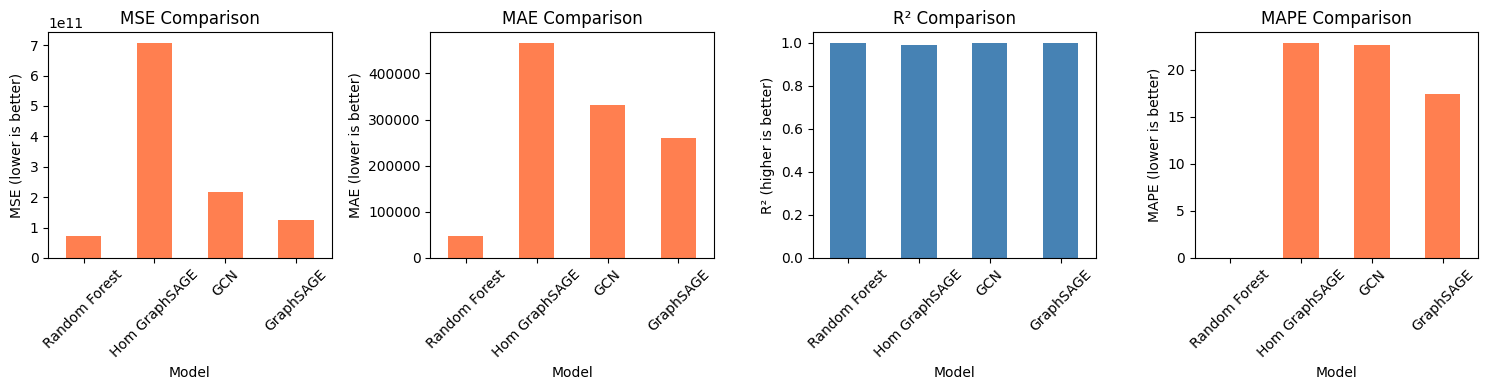


✓ Comparison visualization created


In [ ]:
# ============================================================================
# NEXT-SEASON TASK: Model Comparison
# ============================================================================
# Compares all models trained for the NEXT-SEASON prediction task:
# - Baseline models (Random Forest)
# - GCN (next-season)
# - GraphSAGE (next-season)
# - Homogeneous GraphSAGE (next-season)
#
# Uses baseline_results dictionary which contains metrics for next-season models.
# ============================================================================

# Compare all models
if 'baseline_results' in locals():
    print("=" * 80)
    print("MODEL COMPARISON")
    print("=" * 80)

    # Create comparison DataFrame
    comparison_df = pd.DataFrame(baseline_results).T
    print("\nAll Models - Performance Metrics:")
    print(comparison_df.round(4))

    # Find best model for each metric
    print("\nBest Model by Metric:")
    for metric in ['MSE', 'MAE', 'R²']:
        if metric == 'R²':
            best_model_name = comparison_df[metric].idxmax()
            best_value = comparison_df[metric].max()
        else:
            best_model_name = comparison_df[metric].idxmin()
            best_value = comparison_df[metric].min()
        print(f"  {metric}: {best_model_name} ({best_value:.4f})")

    # Visualize comparison (if matplotlib available)
    try:

        fig, axes = plt.subplots(1, 4, figsize=(15, 4))

        metrics = ['MSE', 'MAE', 'R²', 'MAPE']
        for i, metric in enumerate(metrics):
            ax = axes[i]
            values = comparison_df[metric]
            if metric == 'R²':
                # For R², higher is better
                values.plot(kind='bar', ax=ax, color='steelblue')
                ax.set_ylabel('R² (higher is better)')
            else:
                # For MSE/MAE, lower is better
                values.plot(kind='bar', ax=ax, color='coral')
                ax.set_ylabel(f'{metric} (lower is better)')
            ax.set_title(f'{metric} Comparison')
            ax.set_xlabel('Model')
            ax.tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()
        print("\n✓ Comparison visualization created")
    except ImportError:
        print("\n(Matplotlib not available for visualization)")
else:
    print("⚠️  Baseline results not available. Run baseline and GNN evaluation cells first.")


CURRENT-SEASON MODEL COMPARISON

All Current-Season Models - Performance Metrics:
                         MAPE           MSE          MAE      R²
GCN (curr)            18.8461  2.347912e+11  350533.5686  0.9974
GraphSAGE (curr)      24.6236  3.583268e+11  405720.9675  0.9960
Hom GraphSAGE (curr)  19.2648  7.340972e+11  472129.9792  0.9917

Best Model by Metric (Current-Season):
  MSE: GCN (curr) (234791150571.4690)
  MAE: GCN (curr) (350533.5686)
  R²: GCN (curr) (0.9974)
  MAPE: GCN (curr) (18.8461)


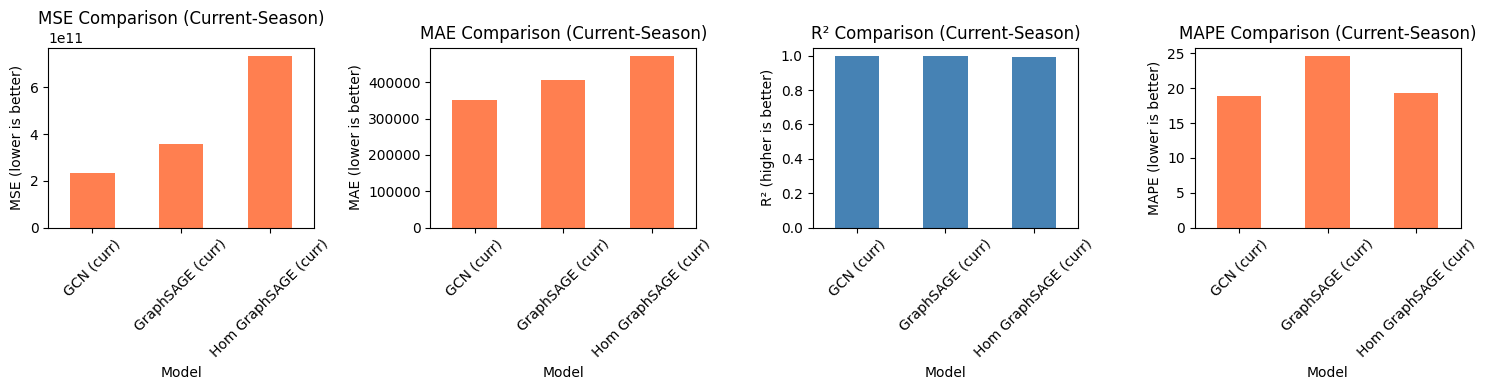


✓ Current-season comparison visualization created


In [ ]:
# ============================================================================
# CURRENT-SEASON TASK: Model Comparison
# ============================================================================
# Compares all models trained for the CURRENT-SEASON prediction task:
# - GCN (current-season)
# - GraphSAGE (current-season)
# - Homogeneous GraphSAGE (current-season)
#
# Uses baseline_results_current dictionary which contains metrics for current-season models.
# ============================================================================

# Compare all current-season models
if 'baseline_results_current' in locals():
    print("=" * 80)
    print("CURRENT-SEASON MODEL COMPARISON")
    print("=" * 80)

    # Create comparison DataFrame
    comparison_df_curr = pd.DataFrame(baseline_results_current).T
    print("\nAll Current-Season Models - Performance Metrics:")
    print(comparison_df_curr.round(4))

    # Find best model for each metric
    print("\nBest Model by Metric (Current-Season):")
    for metric in ['MSE', 'MAE', 'R²', 'MAPE']:
        if metric == 'R²':
            best_model_name = comparison_df_curr[metric].idxmax()
            best_value = comparison_df_curr[metric].max()
        else:
            best_model_name = comparison_df_curr[metric].idxmin()
            best_value = comparison_df_curr[metric].min()
        print(f"  {metric}: {best_model_name} ({best_value:.4f})")

    # Visualize comparison (if matplotlib available)
    try:
        fig, axes = plt.subplots(1, 4, figsize=(15, 4))

        metrics = ['MSE', 'MAE', 'R²', 'MAPE']
        for i, metric in enumerate(metrics):
            ax = axes[i]
            values = comparison_df_curr[metric]
            if metric == 'R²':
                # For R², higher is better
                values.plot(kind='bar', ax=ax, color='steelblue')
                ax.set_ylabel('R² (higher is better)')
            else:
                # For MSE/MAE/MAPE, lower is better
                values.plot(kind='bar', ax=ax, color='coral')
                ax.set_ylabel(f'{metric} (lower is better)')
            ax.set_title(f'{metric} Comparison (Current-Season)')
            ax.set_xlabel('Model')
            ax.tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()
        print("\n✓ Current-season comparison visualization created")
    except ImportError:
        print("\n(Matplotlib not available for visualization)")
else:
    print("⚠️  Current-season model results not available. Run Section 6 current-season training first.")



## 8. Scatterplots

Creates scatter plots comparing model predictions vs actual salaries, separated by task (next-season and current-season).


### Next-Season Task

Scatter plots of model predictions vs actual next-season salary for the test set.

**Task**: Models predict salary for season t+1 using features from season t.  
**Models**: `gcn_model`, `sage_model`, `hom_model` (trained in Section 6)


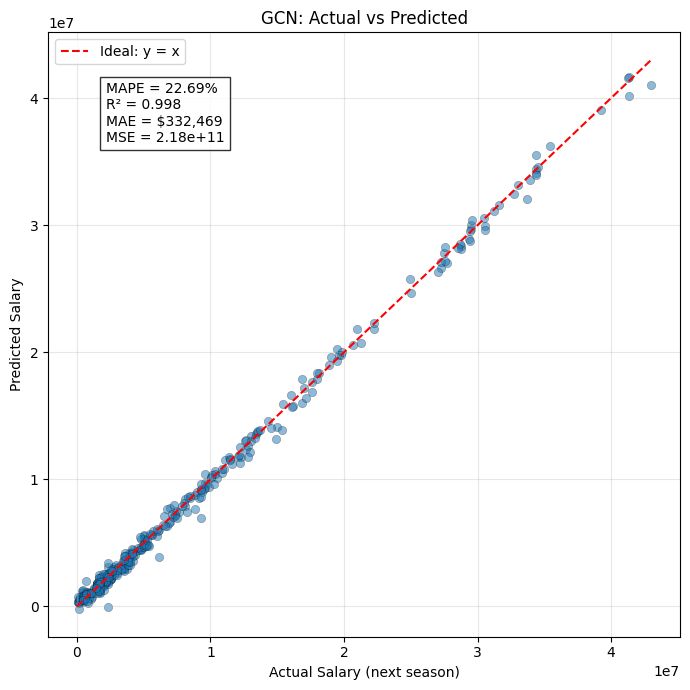


GCN Results:
  MSE: 2.18e+11
  MAE: $332,469
  R²: 0.9975
  MAPE: 22.69%


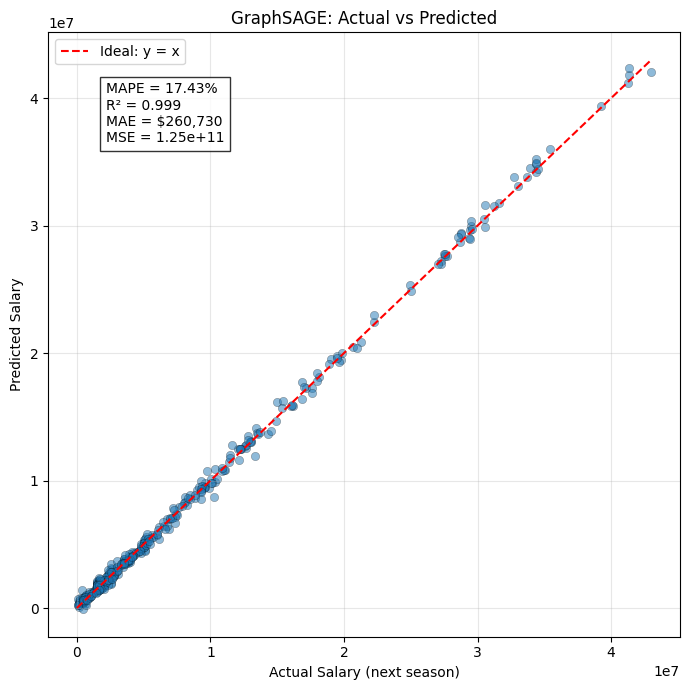


GraphSAGE Results:
  MSE: 1.25e+11
  MAE: $260,730
  R²: 0.9986
  MAPE: 17.43%


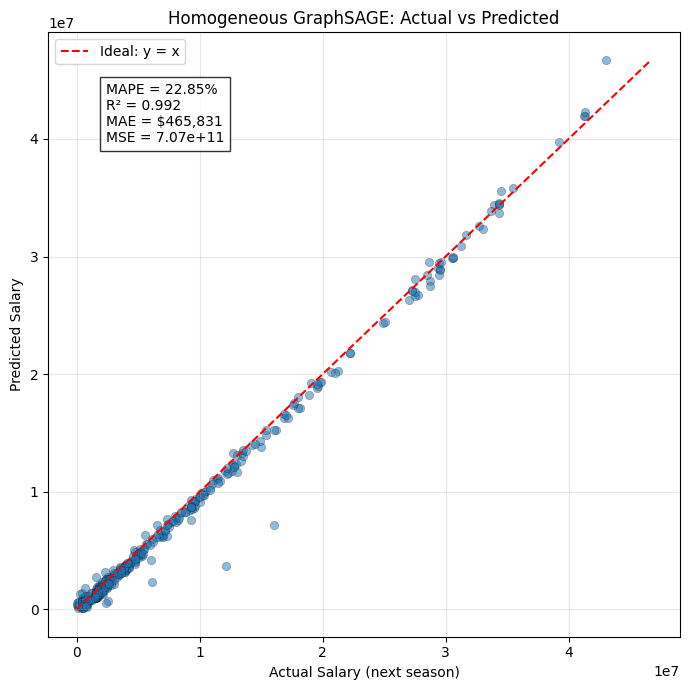


Homogeneous GraphSAGE Results:
  MSE: 7.07e+11
  MAE: $465,831
  R²: 0.9921
  MAPE: 22.85%


In [ ]:
# Plot actual vs predicted salaries for all three models

edge_index_dict = {
    ('player_season', 'plays_for', 'team_season'): data[('player_season', 'plays_for', 'team_season')].edge_index,
    ('player_season', 'teammate', 'player_season'): data[('player_season', 'teammate', 'player_season')].edge_index,
    ('player_season', 'next_season', 'player_season'): data[('player_season', 'next_season', 'player_season')].edge_index,
}
x_dict = {
    'player_season': data['player_season'].x,
    'team_season': data['team_season'].x
}
edge_attr_dict = {
    ('player_season', 'plays_for', 'team_season'): {
        'minutes_played': data[('player_season', 'plays_for', 'team_season')].minutes_played
    }
}

y = data['player_season'].y
y_max = data['player_season'].y_max

# Plot all three models (each in its own figure)

models_to_plot = []
if 'gcn_model' in locals() and hasattr(gcn_model, 'eval'):
    models_to_plot.append(('gcn_model', 'GCN'))
if 'sage_model' in locals() and hasattr(sage_model, 'eval'):
    models_to_plot.append(('sage_model', 'GraphSAGE'))
if 'hom_model' in locals() and hasattr(hom_model, 'eval') and 'hom_data' in locals():
    models_to_plot.append(('hom_model', 'Homogeneous GraphSAGE'))

if len(models_to_plot) == 0:
    raise RuntimeError("No trained models found. Train models before plotting.")

for model_var, model_name in models_to_plot:
    model = locals()[model_var]

    model.eval()
    with torch.no_grad():
        if model_var == 'hom_model':
            # Homogeneous model uses different data structure
            out = model(hom_data.x, hom_data.edge_index)
            preds_norm = out[hom_data.test_mask]
            actual_norm = hom_data.y[hom_data.test_mask]
        else:
            # Heterogeneous models
            out = model(x_dict, edge_index_dict, edge_attr_dict=edge_attr_dict)
            out_ps = out['player_season'] if isinstance(out, dict) else out
            preds_norm = out_ps[player_season_test_mask].squeeze()
            actual_norm = y[player_season_test_mask]

    mask = actual_norm > 0
    if mask.sum() == 0:
        print(f"{model_name}: No valid test targets")
        continue

    preds_norm = preds_norm[mask]
    actual_norm = actual_norm[mask]

    if model_var == 'hom_model':
        preds = preds_norm.cpu().numpy() * hom_data.y_max.item()
        actual = actual_norm.cpu().numpy() * hom_data.y_max.item()
    else:
        preds = preds_norm.cpu().numpy() * y_max.item()
        actual = actual_norm.cpu().numpy() * y_max.item()

    metrics = calculate_metrics(actual, preds)
    metrics['MAPE'] = mape_loss(
        torch.tensor(actual, dtype=torch.float32),
        torch.tensor(preds, dtype=torch.float32)
    ).item()

    plt.figure(figsize=(7, 7))
    plt.scatter(actual, preds, alpha=0.5, edgecolor='k', linewidth=0.3)
    max_val = max(actual.max(), preds.max())
    plt.plot([0, max_val], [0, max_val], 'r--', label='Ideal: y = x')
    plt.xlabel('Actual Salary (next season)')
    plt.ylabel('Predicted Salary')
    plt.title(f'{model_name}: Actual vs Predicted')
    plt.legend()
    plt.grid(True, alpha=0.3)

    text_x = max_val * 0.05
    plt.text(text_x, max_val * 0.85,
            f"MAPE = {metrics['MAPE']:.2f}%\nR² = {metrics['R²']:.3f}\nMAE = ${metrics['MAE']:,.0f}\nMSE = {metrics['MSE']:.2e}",
            bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

    print(f"\n{model_name} Results:")
    for k, v in metrics.items():
        if k == 'MAE':
            print(f"  {k}: ${v:,.0f}")
        elif k == 'MSE':
            print(f"  {k}: {v:.2e}")
        elif k == 'MAPE':
            print(f"  {k}: {v:.2f}%")
        else:
            print(f"  {k}: {v:.4f}")


### Current-Season Task

Scatter plots of model predictions vs actual current-season salary for the test set.

**Task**: Models predict salary for season t using features from season t (same season).  
**Models**: `gcn_model_curr`, `sage_model_curr`, `hom_model_curr` (trained in Section 6)


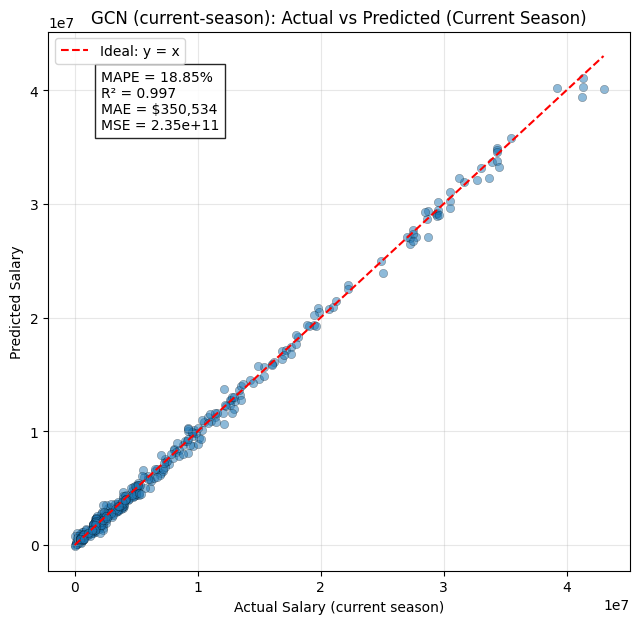

GCN (current-season) metrics:
  MAPE: 18.85%
  R²:  0.9974
  MAE: $350,534
  MSE: 2.35e+11


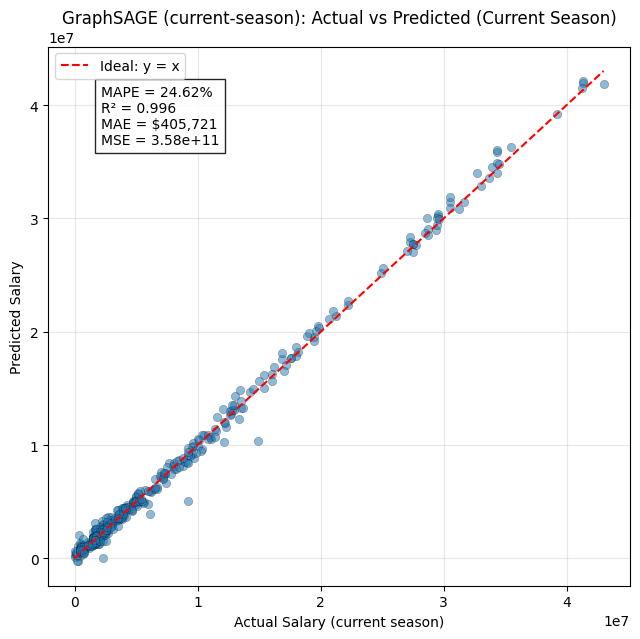

GraphSAGE (current-season) metrics:
  MAPE: 24.62%
  R²:  0.9960
  MAE: $405,721
  MSE: 3.58e+11


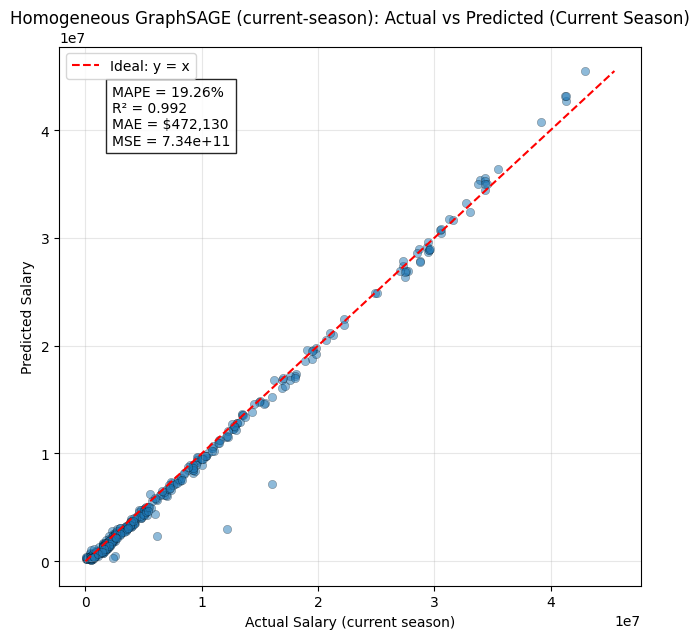

Homogeneous GraphSAGE (current-season) metrics:
  MAPE: 19.26%
  R²:  0.9917
  MAE: $472,130
  MSE: 7.34e+11


In [ ]:
# Plot actual vs predicted for current-season models
# Uses _curr models trained on current-season data

if 'data_curr' not in locals():
    print("Current-season models not trained yet. Please run Section 6 first.")
else:
    edge_index_dict_curr = {
        ('player_season', 'plays_for', 'team_season'): data_curr[('player_season', 'plays_for', 'team_season')].edge_index,
        ('player_season', 'teammate', 'player_season'): data_curr[('player_season', 'teammate', 'player_season')].edge_index,
        ('player_season', 'next_season', 'player_season'): data_curr[('player_season', 'next_season', 'player_season')].edge_index,
    }
    x_dict_curr = {
        'player_season': data_curr['player_season'].x,
        'team_season': data_curr['team_season'].x
    }
    edge_attr_dict_curr = {
        ('player_season', 'plays_for', 'team_season'): {
            'minutes_played': data_curr[('player_season', 'plays_for', 'team_season')].minutes_played
        }
    }

    y_curr = data_curr['player_season'].y
    y_max_curr = data_curr['player_season'].y_max

    def plot_model_predictions_curr(model, name, is_homogeneous=False):
        model.eval()
        with torch.no_grad():
            if is_homogeneous:
                # Homogeneous model uses different data structure
                out = model(hom_data_curr.x, hom_data_curr.edge_index)
                preds_norm = out[hom_data_curr.test_mask]
                actual_norm = hom_data_curr.y[hom_data_curr.test_mask]
                y_max_to_use = hom_data_curr.y_max.item()
            else:
                # Heterogeneous models
                out = model(x_dict_curr, edge_index_dict_curr, edge_attr_dict=edge_attr_dict_curr)
                out_ps = out['player_season'] if isinstance(out, dict) else out
                preds_norm = out_ps[player_season_test_mask_curr].squeeze()
                actual_norm = y_curr[player_season_test_mask_curr]
                y_max_to_use = y_max_curr.item()

        mask = actual_norm > 0
        if mask.sum() == 0:
            print(f"{name}: skipped (no valid test targets)")
            return
        preds_norm = preds_norm[mask]
        actual_norm = actual_norm[mask]
        preds = preds_norm.cpu().numpy() * y_max_to_use
        actual = actual_norm.cpu().numpy() * y_max_to_use
        metrics = calculate_metrics(actual, preds)
        metrics['MAPE'] = mape_loss(
            torch.tensor(actual, dtype=torch.float32),
            torch.tensor(preds, dtype=torch.float32)
        ).item()
        plt.figure(figsize=(6.5, 6.5))
        plt.scatter(actual, preds, alpha=0.5, edgecolor='k', linewidth=0.3)
        max_val = max(actual.max(), preds.max())
        plt.plot([0, max_val], [0, max_val], 'r--', label='Ideal: y = x')
        plt.xlabel('Actual Salary (current season)')
        plt.ylabel('Predicted Salary')
        plt.title(f'{name}: Actual vs Predicted (Current Season)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.text(max_val*0.05, max_val*0.85,
                 f"MAPE = {metrics['MAPE']:.2f}%\nR² = {metrics['R²']:.3f}\nMAE = ${metrics['MAE']:,.0f}\nMSE = {metrics['MSE']:.2e}",
                 bbox=dict(facecolor='white', alpha=0.85))
        plt.tight_layout()
        plt.show()
        print(f"{name} metrics:")
        print(f"  MAPE: {metrics['MAPE']:.2f}%")
        print(f"  R²:  {metrics['R²']:.4f}")
        print(f"  MAE: ${metrics['MAE']:,.0f}")
        print(f"  MSE: {metrics['MSE']:.2e}")

    candidates_curr = [
        ('gcn_model_curr', 'GCN (current-season)', False),
        ('sage_model_curr', 'GraphSAGE (current-season)', False),
        ('hom_model_curr', 'Homogeneous GraphSAGE (current-season)', True),
    ]

    for var_name, display_name, is_hom in candidates_curr:
        obj = locals().get(var_name)
        if obj is not None and hasattr(obj, 'eval'):
            if var_name == 'hom_model_curr' and 'hom_data_curr' not in locals():
                print(f"{display_name}: hom_data_curr not available.")
            else:
                plot_model_predictions_curr(obj, display_name, is_homogeneous=is_hom)
        else:
            print(f"{display_name}: model not available or not trained.")
